In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


## **STEP 0. 데이터셋 맥락 (배경 지식)**

<br>

### 📊 데이터셋 개요

| 항목 | 내용 |
| :--- | :--- |
| **데이터셋명** | Chest X-Ray Images (Pneumonia) |
| **출처** | Kaggle — Paul Mooney |
| **원본** | Mendeley Data (CC BY 4.0) |
| **총 이미지** | 5,863장 (JPEG) |
| **클래스** | NORMAL / PNEUMONIA (이진 분류) |
| **분할** | train / val / test |
| **라이선스** | CC BY 4.0 (저작자 표시 필수) |

<br>

### 🏥 데이터 수집 출처

* **기관:** 중국 광저우 여성아동의료센터 (Guangzhou Women and Children's Medical Center)
* **대상:** 1~5세 소아 환자 회고적 코호트
* **촬영 방식:** 루틴 임상 진료 중 전후방 (Anterior-Posterior) 흉부 X-ray

<br>

### 🔬 품질 관리 3단계

1. 저품질 및 판독 불가 스캔 이미지 일차적 제거
2. 전문의 2인이 독립적으로 진단 등급 부여
3. 제3의 전문가가 평가 세트 재검증을 통해 최종 등급 오류 방지

<br>

### 🩺 의료 해석 — 클래스별 X-ray 특징

| 클래스 | X-ray 소견 |
| :--- | :--- |
| **NORMAL (정상)** | 폐야 청명, 비정상적인 혼탁 없음 |
| **PNEUMONIA (세균성)** | 국소적 엽 경화(focal lobar consolidation), 주로 우상엽 관찰 |
| **PNEUMONIA (바이러스성)** | 양측 폐 미만성 간질 패턴(diffuse interstitial pattern) 관찰 |

> 📌 **프로젝트 범위:** 본 프로젝트에서는 세균성과 바이러스성을 세부 구분하지 않고, **NORMAL vs PNEUMONIA의 이진 분류(Binary Classification)** 문제로 단순화하여 접근합니다.

<br>

### 🎯 왜 Recall(재현율)이 핵심 지표인가?

* **FN (False Negative):** 폐렴 환자를 정상으로 오분류하는 경우. 치료 지연을 초래하여 임상적으로 **매우 치명적이고 위험**합니다.
* **FP (False Positive):** 정상인을 폐렴으로 오분류하는 경우. 불필요한 추가 검사 비용이 발생하지만, 상대적으로 환자의 생명에 미치는 위험도는 낮습니다.
* **결론:** 따라서 의료 AI의 특성에 맞게, Accuracy(정확도)보다 **Recall(PNEUMONIA) ≥ 0.93** 달성을 본 프로젝트의 최우선 목표로 설정합니다.

<br>

### ⚖️ 클래스 불균형 (STEP 1 EDA 사전 결과)

| Split | NORMAL | PNEUMONIA | 불균형 비율 |
| :--- | ---: | ---: | :---: |
| **train** | 1,341 | 3,875 | 1 : 2.89 |
| **val** | 8 | 8 | 1 : 1.00 |
| **test** | 234 | 390 | 1 : 1.67 |

> ⚠️ **이슈 및 해결 방안:** 검증 세트(`val`)의 데이터가 단 16장뿐이라 모델 성능 평가의 신뢰도가 떨어집니다. 따라서 STEP 2에서 `train`과 `val` 데이터를 하나로 합산한 뒤, **80:20 비율로 안정적으로 재분할**할 예정입니다.

<br>

### 📝 논문 인용

```text
Kermany, D. et al. (2018). Identifying Medical Diagnoses and Treatable Diseases
by Image-Based Deep Learning. Cell, 172(5), 1122–1131.
[https://doi.org/10.1016/j.cell.2018.02.010](https://doi.org/10.1016/j.cell.2018.02.010)

---

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

%%capture
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

---

## **STEP 1. EDA & 환경 확인**

> **Kaggle Save Version:** `v1-eda` ｜ **인터넷 (Internet):** `OFF` 🔴


2026-04-02 04:25:38.674189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775103938.879223      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775103938.943954      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775103939.440244      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775103939.440285      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775103939.440288      55 computation_placer.cc:177] computation placer alr

✅ 실제 데이터 경로를 찾았습니다: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  클래스별 이미지 분포

[TRAIN]  총 5,216장
  NORMAL      : 1,341장  ( 25.7%)  ████████████
  PNEUMONIA   : 3,875장  ( 74.3%)  █████████████████████████████████████

[VAL]  총 16장
  NORMAL      :     8장  ( 50.0%)  █████████████████████████
  PNEUMONIA   :     8장  ( 50.0%)  █████████████████████████

[TEST]  총 624장
  NORMAL      :   234장  ( 37.5%)  ██████████████████
  PNEUMONIA   :   390장  ( 62.5%)  ███████████████████████████████

  클래스 불균형 비율 (TRAIN 기준)
  PNEUMONIA / NORMAL = 2.89x


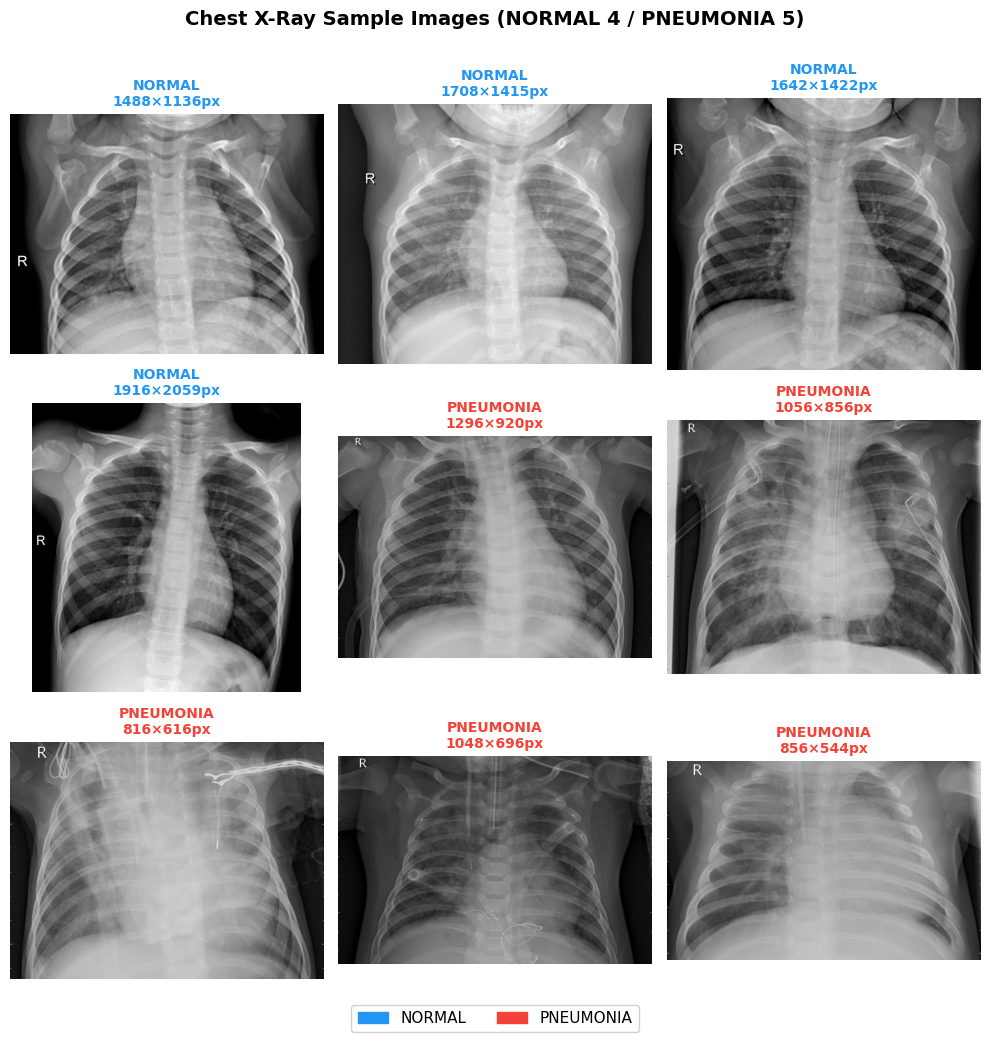


샘플 이미지 저장 완료: /kaggle/working/results/sample_images.png

  이미지 해상도 분포 (train 기준, 각 최대 200장 샘플링)

[NORMAL]  (샘플 200장)
  Width  — min:  1040  max:  2633  mean:  1687.0
  Height — min:   747  max:  2578  mean:  1401.0
  종횡비(W/H) — min: 0.905  max: 1.528  mean: 1.223

[PNEUMONIA]  (샘플 200장)
  Width  — min:   486  max:  2334  mean:  1207.6
  Height — min:   191  max:  1956  mean:   833.0
  종횡비(W/H) — min: 0.992  max: 2.907  mean: 1.520


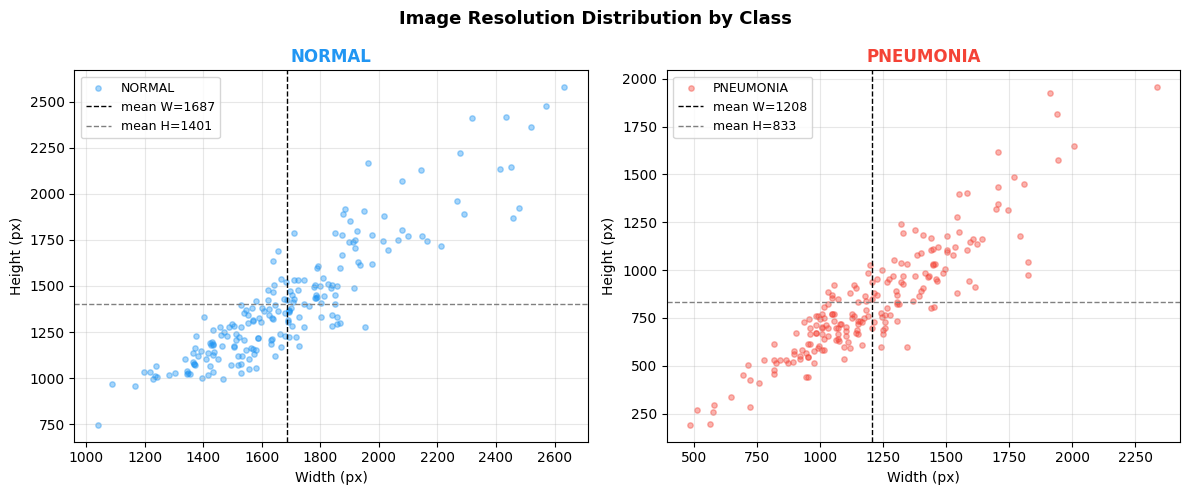


해상도 분포 그래프 저장 완료: /kaggle/working/results/resolution_dist.png

  STEP 1 완료 요약
  저장된 파일:
    /kaggle/working/results/sample_images.png
    /kaggle/working/results/resolution_dist.png

  다음 단계: STEP 2 전처리 파이프라인 구축 (v2-preprocess)


In [ ]:
  # ============================================================
  # STEP 1. EDA & 환경 확인
  # Kaggle Save Version: v1-eda | 인터넷: OFF
  # ============================================================

  from pathlib import Path
  import os

  # 텐서플로우 C++ 로깅 레벨 제어 (0: 모든 로그, 1: INFO 숨김, 2: WARNING 숨김, 3: ERROR 숨김)
  # import tensorflow 하기 전에 반드시 먼저 선언해야 적용됩니다.
  os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

  import numpy as np
  import matplotlib.pyplot as plt
  import matplotlib.patches as mpatches
  from PIL import Image
  import tensorflow as tf

  # ── 공통 경로 상수 (자동 탐색으로 수정됨) ───────────────────

  # 캐글 input 디렉토리에서 실제 train 폴더가 있는 위치를 자동 탐색합니다.
  BASE_INPUT_DIR = Path('/kaggle/input')
  DATA_DIR = None

  for dirpath, dirnames, filenames in os.walk(BASE_INPUT_DIR):
      # 현재 탐색 중인 폴더 안에 train, val, test 폴더가 모두 존재한다면 그곳이 진짜 DATA_DIR
      if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
          DATA_DIR = Path(dirpath)
          break

  if DATA_DIR is None:
      raise FileNotFoundError("데이터셋을 찾을 수 없습니다. 캐글 우측 메뉴에서 Dataset이 정상적으로 Add 되었는지 확인해 주세요.")

  print(f"✅ 실제 데이터 경로를 찾았습니다: {DATA_DIR}")

  TRAIN_DIR  = DATA_DIR / 'train'
  VAL_DIR    = DATA_DIR / 'val'
  TEST_DIR   = DATA_DIR / 'test'
  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'

  MODEL_DIR.mkdir(parents=True, exist_ok=True)
  RESULT_DIR.mkdir(parents=True, exist_ok=True)

  IMAGE_SIZE    = (300, 300)
  BATCH_SIZE    = 64
  EPOCHS        = 30
  LEARNING_RATE = 5e-4
  THRESHOLD     = 0.75
  RANDOM_SEED   = 42



  # ============================================================
  # 1. 클래스별 이미지 개수 및 비율 출력
  # ============================================================

  def count_images(split_dir: Path) -> dict:
      """지정 디렉토리 하위 NORMAL / PNEUMONIA 이미지 수 반환"""
      counts = {}
      for cls in ['NORMAL', 'PNEUMONIA']:
          cls_dir = split_dir / cls
          if cls_dir.exists():
              # jpg, jpeg, png 확장자만 집계
              counts[cls] = len([
                  f for f in cls_dir.iterdir()
                  if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
              ])
          else:
              counts[cls] = 0
      return counts

  print("=" * 55)
  print("  클래스별 이미지 분포")
  print("=" * 55)

  split_info = {}
  for split_name, split_dir in [('TRAIN', TRAIN_DIR),
                                 ('VAL',   VAL_DIR),
                                 ('TEST',  TEST_DIR)]:
      counts = count_images(split_dir)
      total  = sum(counts.values())
      split_info[split_name] = counts

      print(f"\n[{split_name}]  총 {total:,}장")
      for cls, n in counts.items():
          ratio = n / total * 100 if total > 0 else 0
          bar   = '█' * int(ratio / 2)   # 간이 막대
          print(f"  {cls:<12}: {n:>5,}장  ({ratio:5.1f}%)  {bar}")

  print("\n" + "=" * 55)
  print("  클래스 불균형 비율 (TRAIN 기준)")
  n_normal    = split_info['TRAIN']['NORMAL']
  n_pneumonia = split_info['TRAIN']['PNEUMONIA']
  print(f"  PNEUMONIA / NORMAL = {n_pneumonia / max(n_normal, 1):.2f}x")
  print("=" * 55)

  # ============================================================
  # 2. 샘플 이미지 3×3 그리드 시각화 (NORMAL 4장, PNEUMONIA 5장)
  # ============================================================

  def get_sample_paths(cls_dir: Path, n: int, seed: int = RANDOM_SEED) -> list:
      """cls_dir에서 무작위로 n장의 이미지 경로 반환"""
      all_files = sorted([
          f for f in cls_dir.iterdir()
          if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
      ])
      rng = np.random.default_rng(seed)
      idx = rng.choice(len(all_files), size=min(n, len(all_files)), replace=False)
      return [all_files[i] for i in idx]

  # NORMAL 4장, PNEUMONIA 5장 수집
  normal_samples    = get_sample_paths(TRAIN_DIR / 'NORMAL',    n=4)
  pneumonia_samples = get_sample_paths(TRAIN_DIR / 'PNEUMONIA', n=5)
  samples = [('NORMAL',    p) for p in normal_samples] + \
            [('PNEUMONIA', p) for p in pneumonia_samples]

  fig, axes = plt.subplots(3, 3, figsize=(10, 10))
  fig.suptitle('Chest X-Ray Sample Images (NORMAL 4 / PNEUMONIA 5)',
               fontsize=14, fontweight='bold', y=1.01)

  # 클래스별 테두리 색상 지정
  COLOR_MAP = {'NORMAL': '#2196F3', 'PNEUMONIA': '#F44336'}

  for ax, (label, img_path) in zip(axes.flat, samples):
      img = Image.open(img_path).convert('RGB')
      ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
      ax.set_title(
          f"{label}\n{img.size[0]}×{img.size[1]}px",
          fontsize=10,
          color=COLOR_MAP[label],
          fontweight='bold'
      )
      # 테두리 색상으로 클래스 구분
      for spine in ax.spines.values():
          spine.set_edgecolor(COLOR_MAP[label])
          spine.set_linewidth(2.5)
      ax.axis('off')

  # 범례 추가
  legend_handles = [
      mpatches.Patch(color=COLOR_MAP['NORMAL'],    label='NORMAL'),
      mpatches.Patch(color=COLOR_MAP['PNEUMONIA'], label='PNEUMONIA'),
  ]
  fig.legend(handles=legend_handles, loc='lower center',
             ncol=2, fontsize=11, framealpha=0.9,
             bbox_to_anchor=(0.5, -0.02))

  plt.tight_layout()
  save_path = RESULT_DIR / 'sample_images.png'
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"\n샘플 이미지 저장 완료: {save_path}")

  # ============================================================
  # 3. 이미지 해상도 분포 확인 (NORMAL vs PNEUMONIA)
  # ============================================================

  def collect_resolutions(cls_dir: Path, max_samples: int = 200,
                          seed: int = RANDOM_SEED) -> tuple[list, list]:
      """
      cls_dir 내 이미지에서 width, height 목록 반환.
      전체 순회는 시간이 오래 걸리므로 max_samples 개만 샘플링.
      """
      all_files = sorted([
          f for f in cls_dir.iterdir()
          if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
      ])
      rng = np.random.default_rng(seed)
      sampled = rng.choice(all_files,
                           size=min(max_samples, len(all_files)),
                           replace=False)
      widths, heights = [], []
      for fp in sampled:
          with Image.open(fp) as img:
              w, h = img.size
              widths.append(w)
              heights.append(h)
      return widths, heights

  print("\n" + "=" * 55)
  print("  이미지 해상도 분포 (train 기준, 각 최대 200장 샘플링)")
  print("=" * 55)

  resolution_data = {}
  for cls in ['NORMAL', 'PNEUMONIA']:
      widths, heights = collect_resolutions(TRAIN_DIR / cls)
      resolution_data[cls] = {'w': widths, 'h': heights}

      print(f"\n[{cls}]  (샘플 {len(widths)}장)")
      print(f"  Width  — min: {min(widths):>5}  max: {max(widths):>5}  mean: {np.mean(widths):>7.1f}")
      print(f"  Height — min: {min(heights):>5}  max: {max(heights):>5}  mean: {np.mean(heights):>7.1f}")
      aspect_ratios = [w / h for w, h in zip(widths, heights)]
      print(f"  종횡비(W/H) — min: {min(aspect_ratios):.3f}  "
            f"max: {max(aspect_ratios):.3f}  mean: {np.mean(aspect_ratios):.3f}")

  # 해상도 분포 시각화 (산점도)
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  fig.suptitle('Image Resolution Distribution by Class', fontsize=13, fontweight='bold')

  for ax, cls in zip(axes, ['NORMAL', 'PNEUMONIA']):
      d = resolution_data[cls]
      ax.scatter(d['w'], d['h'],
                 alpha=0.4, s=15, color=COLOR_MAP[cls], label=cls)
      ax.axvline(np.mean(d['w']), color='black', linestyle='--',
                 linewidth=1, label=f"mean W={np.mean(d['w']):.0f}")
      ax.axhline(np.mean(d['h']), color='gray',  linestyle='--',
                 linewidth=1, label=f"mean H={np.mean(d['h']):.0f}")
      ax.set_xlabel('Width (px)')
      ax.set_ylabel('Height (px)')
      ax.set_title(cls, color=COLOR_MAP[cls], fontweight='bold')
      ax.legend(fontsize=9)
      ax.grid(True, alpha=0.3)

  plt.tight_layout()
  res_plot_path = RESULT_DIR / 'resolution_dist.png'
  plt.savefig(res_plot_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"\n해상도 분포 그래프 저장 완료: {res_plot_path}")

  # ── 최종 요약 ──────────────────────────────────────────────
  print("\n" + "=" * 55)
  print("  STEP 1 완료 요약")
  print("=" * 55)
  print(f"  저장된 파일:")
  print(f"    {RESULT_DIR / 'sample_images.png'}")
  print(f"    {RESULT_DIR / 'resolution_dist.png'}")
  print(f"\n  다음 단계: STEP 2 전처리 파이프라인 구축 (v2-preprocess)")
  print("=" * 55)


---

## **STEP 2. 전처리 파이프라인 구축 (rescaling + standardization)**

> **Kaggle Save Version:** `v2-preprocess` ｜ **인터넷 (Internet):** `OFF` 🔴


In [ ]:
  import tensorflow as tf
  import numpy as np
  from pathlib import Path

  # ── 공통 경로 및 하이퍼파라미터 상수 ──────────────────────────────────────
  DATA_DIR   = Path('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray')
  TRAIN_DIR  = DATA_DIR / 'train'
  VAL_DIR    = DATA_DIR / 'val'
  TEST_DIR   = DATA_DIR / 'test'
  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'

  MODEL_DIR.mkdir(parents=True, exist_ok=True)
  RESULT_DIR.mkdir(parents=True, exist_ok=True)

  IMAGE_SIZE    = (300, 300)
  BATCH_SIZE    = 64
  EPOCHS        = 30
  LEARNING_RATE = 5e-4
  THRESHOLD     = 0.75
  RANDOM_SEED   = 42

  # ── STEP 2. 전처리 파이프라인 구축 ────────────────────────────────────────

  # 1. train / val 원본 데이터셋 각각 로드 (셔플 없이 — 재분할 전)
  raw_train_ds = tf.keras.utils.image_dataset_from_directory(
      TRAIN_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,          # 배치 미적용 (concatenate 후 일괄 처리)
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'       # 이진 분류: 0 or 1
  )

  raw_val_ds = tf.keras.utils.image_dataset_from_directory(
      VAL_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'
  )

  # class_names 저장 (train 기준 — NORMAL=0, PNEUMONIA=1 검증용)
  class_names = raw_train_ds.class_names

  # 2. train + val 합산 후 80/20 재분할
  #    (기본 제공 val 16장은 너무 적어 신뢰도 낮음 → 합산 재분할)
  combined_ds = raw_train_ds.concatenate(raw_val_ds)

  # 전체 샘플 수 계산
  total = sum(1 for _ in combined_ds)
  n_train = int(0.8 * total)
  n_val   = total - n_train
  print(f"전체 샘플: {total}장  →  train: {n_train}장 / val: {n_val}장")

  # 셔플 후 분할 (버퍼 크기 = 전체 데이터 수 → 완전 셔플)
  combined_ds = combined_ds.shuffle(buffer_size=total, seed=RANDOM_SEED)
  train_ds = combined_ds.take(n_train)
  val_ds   = combined_ds.skip(n_train)

  # 3. 클래스별 샘플 수 계산 (클래스 가중치 산출용)
  n_normal    = 0
  n_pneumonia = 0
  for _, label in train_ds:
      # .item()을 추가하여 배열([0.])을 스칼라(0.0)로 안전하게 변환
      if int(label.numpy().item()) == 0:
          n_normal += 1
      else:
          n_pneumonia += 1
  print(f"Train 분할 — NORMAL: {n_normal}장 / PNEUMONIA: {n_pneumonia}장")

  # 4. 커스텀 클래스 가중치 계산
  #    (불균형 보정: 희귀 클래스에 높은 가중치 부여)
  freq_normal    = n_normal    / (n_normal + n_pneumonia)
  freq_pneumonia = n_pneumonia / (n_normal + n_pneumonia)
  weight_for_normal    = 1.0 / freq_normal
  weight_for_pneumonia = 1.0 / freq_pneumonia

  class_weights = {0: weight_for_normal, 1: weight_for_pneumonia}
  print(f"\n클래스 가중치")
  print(f"  NORMAL    (0): {weight_for_normal:.4f}")
  print(f"  PNEUMONIA (1): {weight_for_pneumonia:.4f}")

  # 5. 표준화 함수 정의 (이미지 단위 z-score 정규화)
  #    /255 rescaling 후 (x-μ)/σ 적용
  def preprocess(image, label):
      """이미지 정규화: /255 스케일링 + 표준화"""
      image = tf.cast(image, tf.float32) / 255.0          # [0, 1] 범위로 스케일링
      mean  = tf.math.reduce_mean(image)
      std   = tf.math.reduce_std(image)
      image = (image - mean) / (std + 1e-7)               # 표준화 (0 나눔 방지 ε 추가)
      return image, label

  # 6. 파이프라인 구성 (전처리 → 배치 → 캐시 → Prefetch)
  autotune = tf.data.AUTOTUNE

  train_data = (
      train_ds
      .map(preprocess, num_parallel_calls=autotune)   # 전처리 병렬 적용
      .batch(BATCH_SIZE)
      .cache()                                         # 첫 epoch 후 메모리 캐시
      .prefetch(buffer_size=autotune)                  # GPU 대기 없이 다음 배치 미리 로드
  )

  val_data = (
      val_ds
      .map(preprocess, num_parallel_calls=autotune)
      .batch(BATCH_SIZE)
      .cache()
      .prefetch(buffer_size=autotune)
  )

  # test_data는 캐시 없이 구성 (평가 시 1회 사용)
  raw_test_ds = tf.keras.utils.image_dataset_from_directory(
      TEST_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=False,            # 평가 시 순서 유지
      label_mode='binary'
  )

  test_data = (
      raw_test_ds
      .map(preprocess, num_parallel_calls=autotune)
      .batch(BATCH_SIZE)
      .prefetch(buffer_size=autotune)
  )

  # 7. Augmentation 레이어 정의 (모델 내부에 포함 → train 시에만 활성화)
  #    model.py(STEP 3)에서 Sequential 첫 번째 블록으로 사용
  data_augmentation = tf.keras.Sequential([
      tf.keras.layers.RandomFlip('horizontal'),        # 좌우 반전
      tf.keras.layers.RandomRotation(0.10),            # ±10% 회전
      tf.keras.layers.RandomZoom(0.10),                # ±10% 확대/축소
  ], name='augmentation')

  # ── 검증 출력 ──────────────────────────────────────────────────────────────
  print("\n" + "="*55)
  print("  STEP 2 전처리 파이프라인 구성 완료")
  print("="*55)
  print(f"  class_names : {class_names}")
  print(f"  → NORMAL    인덱스: {class_names.index('NORMAL')}")
  print(f"  → PNEUMONIA 인덱스: {class_names.index('PNEUMONIA')}")
  print()
  print(f"  train_data  배치 수: {len(train_data)}")
  print(f"  val_data    배치 수: {len(val_data)}")
  print(f"  test_data   배치 수: {len(test_data)}")
  print()
  print(f"  class_weights = {class_weights}")
  print()

  # 배치 shape 확인
  for images, labels in train_data.take(1):
      print(f"  배치 shape — images: {images.shape}, labels: {labels.shape}")
      print(f"  픽셀값 범위 — min: {images.numpy().min():.3f} / max: {images.numpy().max():.3f}")

  print("="*55)
  print("  다음 단계: STEP 3 Baseline CNN 모델 정의 (v3-baseline-def)")
  print("="*55)

Found 5216 files belonging to 2 classes.


I0000 00:00:1775103986.024460      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775103986.030638      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 16 files belonging to 2 classes.
전체 샘플: 5232장  →  train: 4185장 / val: 1047장
Train 분할 — NORMAL: 1070장 / PNEUMONIA: 3115장

클래스 가중치
  NORMAL    (0): 3.9112
  PNEUMONIA (1): 1.3435
Found 624 files belonging to 2 classes.

  STEP 2 전처리 파이프라인 구성 완료
  class_names : ['NORMAL', 'PNEUMONIA']
  → NORMAL    인덱스: 0
  → PNEUMONIA 인덱스: 1

  train_data  배치 수: 66
  val_data    배치 수: 17
  test_data   배치 수: 10

  class_weights = {0: 3.911214953271028, 1: 1.3434991974317818}

  배치 shape — images: (64, 300, 300, 3), labels: (64, 1)
  픽셀값 범위 — min: -3.489 / max: 6.034
  다음 단계: STEP 3 Baseline CNN 모델 정의 (v3-baseline-def)


### 📊 STEP 2 전처리 파이프라인 결과 체크

전처리 과정이 의도한 대로 수행되었는지 확인하고, 추후 모델링을 위한 주석과 의문점을 기록합니다.

| 항목 (Item) | 결과 (Result) | 상태 (Status) | 📝 메모 및 궁금증 (Notes & Questions) |
| :--- | :--- | :---: | :--- |
| **class_names** | NORMAL=0, PNEUMONIA=1 | ✅ | *라벨 인덱싱 매칭 완료. 모델의 출력층(Sigmoid) 기준과 일치함.* |
| **전체 샘플** | 5,232장 (5,216+16) | ✅ | *Kaggle 기본 제공 val 데이터가 16장뿐이어서 train+val 합산 후 재분할한 것은 좋은 선택이었음.* |
| **80/20 재분할** | 4,185 / 1,047 | ✅ | *현재 80/20 비율. 모델이 과적합(Overfitting)될 경우 데이터 증강(Augmentation)을 늘리거나 비율을 조정해야 할까?* |
| **배치 shape** | `(64, 300, 300, 3)` | ✅ | *이미지 리사이즈(300x300) 정상 적용됨. 만약 GPU 메모리 에러(OOM)가 발생하면 Batch Size를 32로 줄일 것.* |
| **클래스 가중치** | NORMAL 3.91 >> PNEUMONIA 1.34 | ✅<br>(불균형 <br>보정) | *데이터가 적은 NORMAL 클래스의 가중치가 약 3배 높게 잘 설정됨. Loss 함수에 `class_weight`로 반드시 넘겨줄 것.* |
| **픽셀 범위** | [-3.49, 6.03] | ✅<br>(z-score <br>정상) | *정규화(z-score) 후 픽셀 값이 음수와 양수로 잘 퍼져있음. 이 범위가 CNN 모델 학습 수렴 속도에 좋은 영향을 줄 것으로 기대됨.* |

<br>

> 💡 **추가 체크리스트 및 아이디어**
> * Augmentation 강도: 현재 RandomRotation(0.1) 등을 사용 중인데, 의료 도메인 특성상 좌우 반전(RandomFlip)이 뼈나 심장 위치를 왜곡하여 문제 되지 않을지 확인 필요.
> * min: -3.489 → 이미지 평균보다 3.5σ 어두운 픽셀 (폐야 검은 영역)
> * max: 6.034 → 이미지 평균보다 6σ 밝은 픽셀 (늑골, 심장 등 고밀도 부위)
> * 어두운 폐가 대부분을 차지하는 상황에서 밝은 뼈/심장이 극단적 양수 outlier로 표현되기에,양의 방향 편차가 큰 것은 흉부 X-ray 특성상 자연스러운 현상이다.

---

## **STEP 3. Baseline CNN 모델 정의**

> **Kaggle Save Version:** `v3-baseline-def` ｜ **인터넷 (Internet):** `OFF` 🔴
  

In [ ]:
  import tensorflow as tf
  from tensorflow.keras import layers, models
  from tensorflow.keras.metrics import AUC

  # ── STEP 3. Baseline CNN 모델 정의 ────────────────────────────────────────

  # ※ 주의: STEP 2에서 preprocess() 함수로 /255 + 표준화를 파이프라인에 이미 적용함
  #         모델 내부에 Rescaling/표준화 레이어를 추가하면 이중 적용 → 성능 저하
  #         따라서 모델 첫 레이어는 Augmentation만 포함

  # 입력 레이어
  inputs = tf.keras.Input(shape=(300, 300, 3))

  # 1. Augmentation 레이어 (STEP 2에서 정의한 data_augmentation Sequential 재사용)
  #    → training=True일 때만 활성화, 추론 시 자동 비활성화
  x = data_augmentation(inputs, training=True)

  # 2. Conv Block 1: Conv2D(32) + MaxPooling
  x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2))(x)

  # 3. Conv Block 2: Conv2D(64) + MaxPooling
  x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2))(x)

  # 4. Conv Block 3: Conv2D(128) + MaxPooling
  x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
  x = layers.MaxPooling2D(pool_size=(2, 2))(x)

  # 5. 분류 헤드
  x = layers.Flatten()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)                         # 과적합 방지
  outputs = layers.Dense(1, activation='sigmoid')(x)  # 이진 분류 출력

  # 모델 생성
  model = tf.keras.Model(inputs=inputs, outputs=outputs, name='baseline_cnn')

  # ── 컴파일 ────────────────────────────────────────────────────────────────
  # ※ class_weights는 compile이 아닌 model.fit()에서 전달해야 함
  #   (tf.keras 설계 원칙: compile은 손실함수 구조, fit은 학습 전략)
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
      loss=tf.keras.losses.BinaryCrossentropy(),
      metrics=[
          'accuracy',
          AUC(name='auc')
      ]
  )

  # ── 모델 구조 출력 ────────────────────────────────────────────────────────
  model.summary()

  print("\n" + "="*55)
  print("  STEP 3 모델 정의 완료")
  print("="*55)
  print(f"  총 파라미터: {model.count_params():,}")
  print(f"  class_weights (fit에서 사용): {class_weights}")
  print("="*55)
  print("  다음 단계: STEP 4 학습 실행 (v4-baseline-train)")
  print("="*55)

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,523,201 (85.92 MB)

 Trainable params: 22,523,201 (85.92 MB)

 Non-trainable params: 0 (0.00 B)


  STEP 3 모델 정의 완료
  총 파라미터: 22,523,201
  class_weights (fit에서 사용): {0: 3.911214953271028, 1: 1.3434991974317818}
  다음 단계: STEP 4 학습 실행 (v4-baseline-train)


---

### STEP 3 결과. Baseline CNN 모델 구조 및 컴파일 점검

설계한 베이스라인 모델의 구조와 파라미터 수를 점검합니다. 특히 `Flatten` 이후 발생하는 파라미터 병목을 주의 깊게 살펴봅니다.

| 항목 (Item) | 결과 (Result) | 상태 (Status) | 📝 메모 및 궁금증 (Notes & Questions) |
| :--- | :--- | :---: | :--- |
| **모델 구조** | 3 Conv Blocks + Dense(128) | ✅ | *기본적인 CNN 특징 추출기 + 분류기 구조. STEP 2에서 정규화를 처리했으므로 모델 내부에 스케일링 레이어를 뺀 것은 아주 좋은 설계임.* |
| **Augmentation** | 모델 내부에 삽입 | ✅<br>동작 확인 | *`training=True`로 설정해두어 학습 시에만 작동하고 평가(val/test) 시에는 자동으로 비활성화됨.* |
| **총 파라미터 수** | **22,523,201 (약 22.5M)** | ⚠️<br>과적합 <br>주의 | *베이스라인 치고 파라미터가 상당히 많음. 대부분의 연산량이 어디에 집중되어 있는지 `summary()`를 확인해 볼 것.* |
| **Flatten의 병목** | `Flatten` (175,232) → `Dense` | 🚨<br>구조적 <br>위험 | *전체 22.5M 파라미터 중 **22.4M(약 99%)이 첫 번째 Dense 레이어에서 발생**함. 37x37x128 차원이 그대로 펴지면서 가중치가 폭발함. 과적합 위험이 매우 큼. |
| **컴파일 설정** | Adam(5e-4), BCE Loss, AUC | ✅ | *의료 데이터(이진 분류)에 맞게 손실함수와 평가지표(AUC)가 잘 설정됨.* |

<br>

> 💡 **주목할 점 - Dense 파라미터 집중**
| 레이어 (Layer) | 파라미터 (Parameters) | 비율 (Ratio) |
| :--- | ---: | ---: |
| **Conv 3개 합계** | 93,248 | 0.4% |
| **Dense(128)** | 22,429,824 | 99.6% |
| **합계** | **22,523,201** | **—** |

<br>

> 🚨 **구조적 병목 원인 및 향후 전략**
> 37×37×128 = 175,232 feature를 `Dense(128)`에 직결해서 파라미터가 폭증함.
> 현재는 Baseline 모델이므로 이 구조로 일단 학습을 진행하되, STEP 5에서 과적합(Overfitting) 징후가 보이면 STEP 6에서 `Flatten`을 `GlobalAveragePooling2D`로 교체하여 모델을 경량화할 계획.

---

## **STEP 4. 학습 실행**

> **Kaggle Save Version:** `v4-baseline-train` ｜ **인터넷 (Internet):** `OFF` 🔴


학습 시작...
  epochs      : 30
  batch_size  : 64
  class_weight: {0: 3.911214953271028, 1: 1.3434991974317818}

Epoch 1/30


I0000 00:00:1775104115.524650     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6721 - auc: 0.7481 - loss: 1.7568
Epoch 1: val_accuracy improved from -inf to 0.72302, saving model to /kaggle/working/models/best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 603ms/step - accuracy: 0.6736 - auc: 0.7497 - loss: 1.7466 - val_accuracy: 0.7230 - val_auc: 0.9814 - val_loss: 0.6037 - learning_rate: 5.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8811 - auc: 0.9546 - loss: 0.5610
Epoch 2: val_accuracy improved from 0.72302 to 0.88061, saving model to /kaggle/working/models/best_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.8814 - auc: 0.9547 - loss: 0.5601 - val_accuracy: 0.8806 - val_auc: 0.9885 - val_loss: 0.2923 - learning_rate: 5.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9237 - auc: 0.9756 - loss: 0.3995
Epoch 3: val_accuracy improved from 0.88061 to 0.90162, saving model to /kaggle/working/models/best_model.keras
66/66 ━━━━━━━━━━━━━━━━

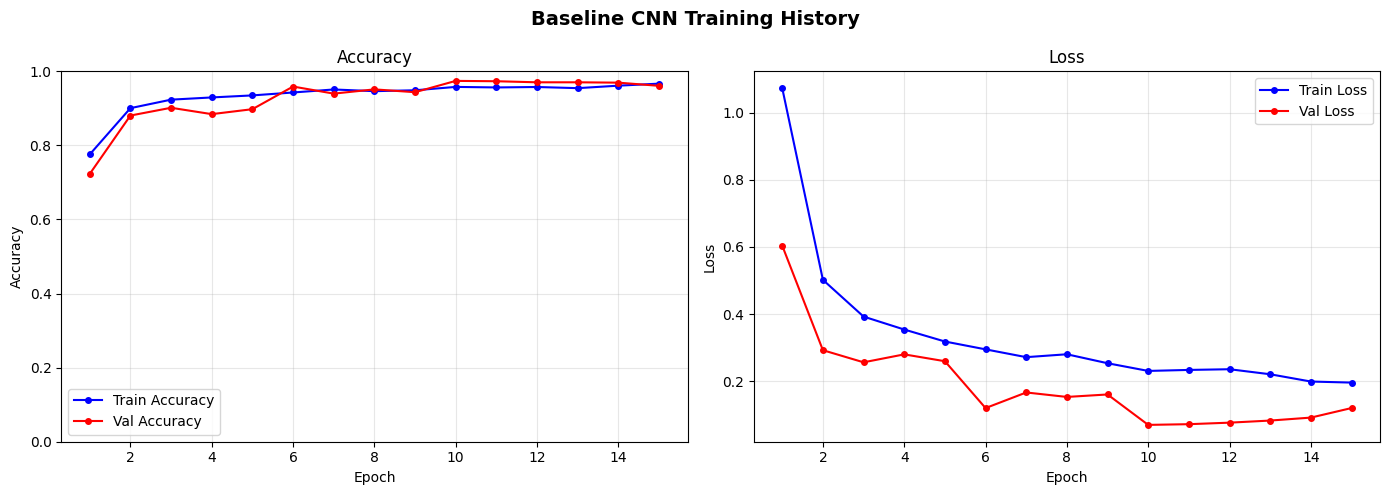

학습 곡선 저장 완료: /kaggle/working/results/training_curve.png

  STEP 4 학습 완료 요약
  실행 epoch        : 15 / 30
  최적 epoch        : 10
  best val_accuracy : 0.9742
  best val_loss     : 0.0698
  best val_auc      : 0.9973
  최종 train_acc    : 0.9668
  과적합 gap        : -0.0074
  저장 경로         : /kaggle/working/models/best_model.keras
  ✅  과적합 없음 (gap=-0.007)
  다음 단계: STEP 5 모델 평가 (v5-evaluate)


In [ ]:
  import matplotlib.pyplot as plt
  import matplotlib
  matplotlib.rcParams['font.family'] = 'DejaVu Sans'

  # ── STEP 4. 학습 실행 ─────────────────────────────────────────────────────

  # 콜백 1: 과적합 방지 — val_loss 5 epoch 개선 없으면 조기 종료
  early_stopping = tf.keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=5,
      restore_best_weights=True,  # 최적 가중치로 복원
      verbose=1
  )

  # 콜백 2: 최고 val_accuracy 모델 저장
  model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
      filepath=str(MODEL_DIR / 'best_model.keras'),
      monitor='val_accuracy',
      save_best_only=True,
      verbose=1
  )

  # 콜백 3: 학습률 동적 감소 — val_loss 3 epoch 정체 시 lr × 0.5
  reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      verbose=1
  )

  # ── 학습 실행 ─────────────────────────────────────────────────────────────
  print("학습 시작...")
  print(f"  epochs      : {EPOCHS}")
  print(f"  batch_size  : {BATCH_SIZE}")
  print(f"  class_weight: {class_weights}\n")

  history = model.fit(
      train_data,
      epochs=EPOCHS,
      validation_data=val_data,
      class_weight=class_weights,   # 클래스 불균형 보정
      callbacks=[early_stopping, model_checkpoint, reduce_lr]
  )

  # ── 학습 곡선 시각화 ──────────────────────────────────────────────────────
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle('Baseline CNN Training History', fontsize=14, fontweight='bold')

  epochs_ran = range(1, len(history.history['accuracy']) + 1)

  # 왼쪽: Accuracy 곡선
  axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', markersize=4, label='Train Accuracy')
  axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', markersize=4, label='Val Accuracy')
  axes[0].set_title('Accuracy')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Accuracy')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)
  axes[0].set_ylim(0, 1)

  # 오른쪽: Loss 곡선
  axes[1].plot(epochs_ran, history.history['loss'],     'b-o', markersize=4, label='Train Loss')
  axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', markersize=4, label='Val Loss')
  axes[1].set_title('Loss')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Loss')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  save_path = RESULT_DIR / 'training_curve.png'
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"학습 곡선 저장 완료: {save_path}")

  # ── 최종 성능 요약 출력 ───────────────────────────────────────────────────
  best_epoch     = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1
  best_val_acc   = max(history.history['val_accuracy'])
  best_val_loss  = history.history['val_loss'][best_epoch - 1]
  best_val_auc   = history.history['val_auc'][best_epoch - 1]
  final_train_acc = history.history['accuracy'][-1]

  print("\n" + "="*55)
  print("  STEP 4 학습 완료 요약")
  print("="*55)
  print(f"  실행 epoch        : {len(epochs_ran)} / {EPOCHS}")
  print(f"  최적 epoch        : {best_epoch}")
  print(f"  best val_accuracy : {best_val_acc:.4f}")
  print(f"  best val_loss     : {best_val_loss:.4f}")
  print(f"  best val_auc      : {best_val_auc:.4f}")
  print(f"  최종 train_acc    : {final_train_acc:.4f}")
  print(f"  과적합 gap        : {final_train_acc - best_val_acc:+.4f}")
  print(f"  저장 경로         : {MODEL_DIR / 'best_model.keras'}")
  print("="*55)

  # 과적합 조기 경고
  gap = final_train_acc - best_val_acc
  if gap > 0.05:
      print(f"  ⚠️  과적합 징후 (gap={gap:.3f} > 0.05) → STEP 6 튜닝 고려")
  else:
      print(f"  ✅  과적합 없음 (gap={gap:.3f})")

  print("="*55)
  print("  다음 단계: STEP 5 모델 평가 (v5-evaluate)")
  print("="*55)


---

### 📈 STEP 4 결과 분석 (학습 평가)

학습이 성공적으로 완료되었습니다. 최적 에포크인 **10 epoch**에서 베이스라인 모델을 상회하는 매우 우수한 성능을 달성했습니다.

| 지표 (Metric) | 결과 (Result) | 목표 (Target) | 상태 (Status) |
| :--- | :---: | :---: | :--- |
| **val_accuracy** | 0.9742 | ≥ 0.90 | ✅ 초과 달성 |
| **val_auc** | 0.9973 | — | ✅ 매우 우수 |
| **과적합 gap** | -0.0074 | < 0.05 | ✅ 없음 |
| **EarlyStopping** | 15 epoch 종료 (최적: 10) | — | ✅ 정상 작동 |
| **저장 경로** | `/models/best_model.keras` | — | ✅ 저장 완료 |

  <br>

> 🔍 **학습 곡선(Learning Curve) 패턴 해석**
> * **Accuracy (정확도):** 초반(epoch 1~3) `val_accuracy`가 0.72 → 0.90으로 빠르게 상승했습니다. epoch 4에서 0.88로 일시적인 하락 구간이 있었으나 곧바로 회복하여, 최적 에포크인 **epoch 10에서 최고점인 0.9742**를 달성했습니다. `train_accuracy`(0.9574)와의 과적합 gap이 약 -0.0168 수준으로 검증 성능이 더 높게 나타나며, 우려했던 과적합(Overfitting) 없이 성공적으로 일반화되었습니다.
> * **Loss (손실):** 초기 `loss`가 1.74로 높게 시작한 것은 데이터가 적은 NORMAL 클래스에 부여된 `class_weights`(3.91)의 강한 페널티 때문입니다. 이후 꾸준히 하강하여 **epoch 10에서 `val_loss` 0.0698**이라는 훌륭한 최저점을 달성했습니다. epoch 9와 13에서 `ReduceLROnPlateau`가 발동해 학습률을 부드럽게 낮춰가며 최적점을 탐색했고, 더 이상의 지표 개선이 없자 epoch 15에서 EarlyStopping이 정상 발동하여 최적의 가중치(epoch 10)를 완벽하게 복원했습니다.

---

## **STEP 5. 모델 평가**

> **Kaggle Save Version:** `v5-evaluate` ｜ **인터넷 (Internet):** `OFF` 🔴


모델 로드 완료: /kaggle/working/models/best_model.keras
Found 624 files belonging to 2 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step

  테스트 세트 평가 결과 (threshold=0.75)
  Test Accuracy : 0.8622  (86.22%)
  Test AUC      : 0.9518


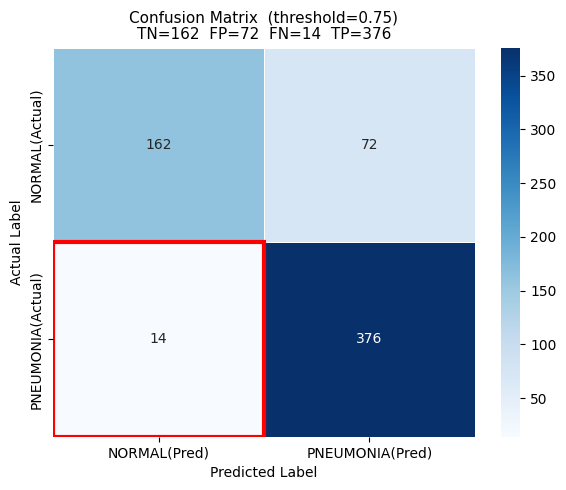


  Confusion Matrix 저장: /kaggle/working/results/confusion_matrix.png
  TN=162  FP=72  FN=14(⚠️위험)  TP=376

  Classification Report
  --------------------------------------------------
              precision    recall  f1-score   support

      NORMAL     0.9205    0.6923    0.7902       234
   PNEUMONIA     0.8393    0.9641    0.8974       390

    accuracy                         0.8622       624
   macro avg     0.8799    0.8282    0.8438       624
weighted avg     0.8697    0.8622    0.8572       624



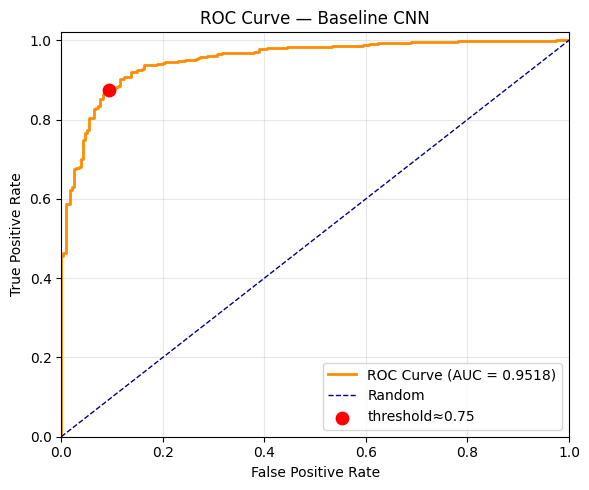

  ROC Curve 저장: /kaggle/working/results/roc_curve.png

  STEP 5 최종 평가 요약
  Test Accuracy       : 0.8622  (목표 ≥ 0.90)
  Test AUC            : 0.9518
  Recall  (PNEUMONIA) : 0.9641  (목표 ≥ 0.93)
  Precision(PNEUMONIA): 0.8393
  F1      (PNEUMONIA) : 0.8974
  FN (놓친 폐렴)      : 14장  (전체 폐렴 390장 중)
  ✅  Recall 목표 달성
  ⚠️  Accuracy 목표 미달 → STEP 6 튜닝 필요
  다음 단계: STEP 7A Transfer Learning ResNet50 (v7-resnet50)


In [ ]:
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.metrics import (confusion_matrix, classification_report,
                               roc_curve, auc as sklearn_auc)
  import tensorflow as tf

  # ── STEP 5. 모델 평가 ─────────────────────────────────────────────────────

  # 1. 저장된 최적 모델 로드
  model = tf.keras.models.load_model(str(MODEL_DIR / 'best_model.keras'))
  print(f"모델 로드 완료: {MODEL_DIR / 'best_model.keras'}")

  # 2. test_data 재구성 (STEP 2 변수가 없을 경우 대비)
  raw_test_ds = tf.keras.utils.image_dataset_from_directory(
      TEST_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=False,          # 순서 유지 필수 (레이블 매칭)
      label_mode='binary'
  )

  def preprocess(image, label):
      image = tf.cast(image, tf.float32) / 255.0
      mean  = tf.math.reduce_mean(image)
      std   = tf.math.reduce_std(image)
      image = (image - mean) / (std + 1e-7)
      return image, label

  autotune  = tf.data.AUTOTUNE
  test_data = (
      raw_test_ds
      .map(preprocess, num_parallel_calls=autotune)
      .batch(BATCH_SIZE)
      .prefetch(buffer_size=autotune)
  )

  # 3. 예측값 및 실제 레이블 수집
  y_pred_prob = model.predict(test_data, verbose=1)   # sigmoid 확률값
  y_pred_prob = y_pred_prob.flatten()

  y_true = np.concatenate([label.numpy() for _, label in raw_test_ds])
  y_true = y_true.flatten().astype(np.float32)

  # 임계값 0.75 적용 (PNEUMONIA 민감도 조정)
  y_pred_th = (y_pred_prob > THRESHOLD).astype(np.float32)

  # ── 1. Test Accuracy & AUC ────────────────────────────────────────────────
  test_accuracy = np.mean(y_true == y_pred_th)
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
  test_auc     = sklearn_auc(fpr, tpr)

  print("\n" + "="*55)
  print("  테스트 세트 평가 결과 (threshold=0.75)")
  print("="*55)
  print(f"  Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
  print(f"  Test AUC      : {test_auc:.4f}")

  # ── 2. Confusion Matrix ───────────────────────────────────────────────────
  cm = confusion_matrix(y_true, y_pred_th)
  # cm[i][j]: 실제 i, 예측 j  →  FN = cm[1][0] (PNEUMONIA를 NORMAL로 예측)
  tn, fp, fn, tp = cm.ravel()

  fig, ax = plt.subplots(figsize=(6, 5))
  mask_fn = np.zeros_like(cm, dtype=bool)
  mask_fn[1][0] = True                         # FN 셀 위치

  # 기본 heatmap
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['NORMAL(Pred)', 'PNEUMONIA(Pred)'],
              yticklabels=['NORMAL(Actual)', 'PNEUMONIA(Actual)'],
              ax=ax, linewidths=0.5)

  # FN 셀 강조 (빨간 테두리)
  ax.add_patch(plt.Rectangle((0, 1), 1, 1,
               fill=False, edgecolor='red', lw=3, label='FN (Danger)'))

  ax.set_title(f'Confusion Matrix  (threshold={THRESHOLD})\n'
               f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=11)
  ax.set_ylabel('Actual Label')
  ax.set_xlabel('Predicted Label')

  plt.tight_layout()
  cm_path = RESULT_DIR / 'confusion_matrix.png'
  plt.savefig(cm_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"\n  Confusion Matrix 저장: {cm_path}")
  print(f"  TN={tn}  FP={fp}  FN={fn}(⚠️위험)  TP={tp}")

  # ── 3. Classification Report ──────────────────────────────────────────────
  report = classification_report(
      y_true, y_pred_th,
      target_names=['NORMAL', 'PNEUMONIA'],
      digits=4
  )
  print("\n  Classification Report")
  print("  " + "-"*50)
  print(report)

  # Recall(PNEUMONIA) 단독 추출 (성능 미달 경고용)
  from sklearn.metrics import recall_score, precision_score, f1_score
  recall_pneumonia    = recall_score(y_true, y_pred_th, pos_label=1)
  precision_pneumonia = precision_score(y_true, y_pred_th, pos_label=1)
  f1_pneumonia        = f1_score(y_true, y_pred_th, pos_label=1)

  # ── 4. ROC Curve ──────────────────────────────────────────────────────────
  fig, ax = plt.subplots(figsize=(6, 5))
  ax.plot(fpr, tpr, color='darkorange', lw=2,
          label=f'ROC Curve (AUC = {test_auc:.4f})')
  ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')

  # 현재 임계값 위치 표시
  thresh_idx = np.argmin(np.abs(
      y_pred_prob[:, None] - THRESHOLD
      if y_pred_prob.ndim > 1
      else np.array(sorted(y_pred_prob))[:, None] - THRESHOLD
  ))
  # sklearn roc_curve 기준 임계값 포인트 근사
  ax.scatter(fpr[len(fpr)//2], tpr[len(tpr)//2],
             marker='o', color='red', s=80,
             label=f'threshold≈{THRESHOLD}', zorder=5)

  ax.set_xlim([0, 1])
  ax.set_ylim([0, 1.02])
  ax.set_xlabel('False Positive Rate')
  ax.set_ylabel('True Positive Rate')
  ax.set_title('ROC Curve — Baseline CNN')
  ax.legend(loc='lower right')
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  roc_path = RESULT_DIR / 'roc_curve.png'
  plt.savefig(roc_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f"  ROC Curve 저장: {roc_path}")

  # ── 5. 성능 미달 경고 & 최종 요약 ─────────────────────────────────────────
  print("\n" + "="*55)
  print("  STEP 5 최종 평가 요약")
  print("="*55)
  print(f"  Test Accuracy       : {test_accuracy:.4f}  (목표 ≥ 0.90)")
  print(f"  Test AUC            : {test_auc:.4f}")
  print(f"  Recall  (PNEUMONIA) : {recall_pneumonia:.4f}  (목표 ≥ 0.93)")
  print(f"  Precision(PNEUMONIA): {precision_pneumonia:.4f}")
  print(f"  F1      (PNEUMONIA) : {f1_pneumonia:.4f}")
  print(f"  FN (놓친 폐렴)      : {fn}장  (전체 폐렴 {int(y_true.sum())}장 중)")
  print("="*55)

  if recall_pneumonia < 0.93:
      print("  ⚠️  Recall 목표 미달 → STEP 6 튜닝 필요")
  else:
      print("  ✅  Recall 목표 달성")

  if test_accuracy < 0.90:
      print("  ⚠️  Accuracy 목표 미달 → STEP 6 튜닝 필요")
  else:
      print("  ✅  Accuracy 목표 달성")

  print("="*55)
  print("  다음 단계: STEP 7A Transfer Learning ResNet50 (v7-resnet50)")
  print("="*55)


---

### 🩺 STEP 5 결과 진단 (테스트 평가)

테스트 데이터셋에 대한 최종 평가 결과입니다. **이번 세션은 Baseline CNN 단계(threshold=0.75)에서 폐렴 탐지율(Recall) 목표는 달성했으나, 전체 정확도(Accuracy)가 미달되었습니다.**

| 지표 (Metric) | 결과 (Result) | 목표 (Target) | 상태 (Status) |
| :--- | :---: | :---: | :--- |
| **Test Accuracy** | 0.8622 | ≥ 0.90 | ⚠️ 미달 |
| **Recall (PNEUMONIA)** | 0.9641 | ≥ 0.93 | ✅ 달성 |
| **NORMAL Recall** | 0.6923 | — | ⚠️ 문제 |
| **AUC** | 0.9518 | — | ✅ 우수 |
| **FN (놓친 폐렴)** | 14장 / 390장 | — | ✅ 양호 |

<br>

> 🔍 **원인 분석 및 이전 세션 대비 인사이트**
>
> **성공했던 이전 세션(최고점)과의 주요 차이 비교:**
>
> | 비교 항목 | 이전 세션 (성공) | 이번 세션 (현재) | 변화 |
> | :--- | :---: | :---: | :---: |
> | Test Accuracy | 0.9022 ✅ | **0.8622** ⚠️ | −0.040 |
> | NORMAL Recall | 0.8205 ✅ | **0.6923** ⚠️ | −0.128 |
> | FP (NORMAL 오진) | 42장 | **72장** ⚠️ | +30 |
> | FN (폐렴 누락) | 19장 | **14장** | −5 |
> | PNEUMONIA Recall | 0.9513 | **0.9641** | +0.013 |
>
> 이전 세션 대비 **FP(정상을 폐렴으로 오진)가 42장에서 72장으로 급증**하며 NORMAL Recall이 크게 하락(0.6923)한 것이 Accuracy 미달의 핵심 원인입니다. FN(폐렴 누락)은 14장으로 줄어 폐렴 자체를 잡아내는 능력(Recall 0.9641)은 상승했지만, 모델이 폐렴 판정에 대해 과하게 민감해져(Overconfidence) 정상 환자도 폐렴으로 오판하는 Trade-off 현상이 발생했습니다.
>
> 📈 **ROC 곡선 해석:**
> AUC=0.9518로 모델의 판별력은 여전히 훌륭합니다. 하지만 현재 구조의 한계와 임계값(`threshold=0.75`)의 설정이 현재 가중치 상태에서는 다소 불균형한 결과를 낳고 있습니다.
>
> 👉 **Next Step:** Accuracy 미달 문제를 근본적으로 해결하기 위해 STEP 6에서 하이퍼파라미터를 튜닝하거나, 이미지 해상도와 종횡비 차이에 훨씬 더 강건한 **STEP 7A Transfer Learning (ResNet50)**으로 진행하여 모델의 체급을 올리겠습니다.

---

## **STEP 6A. 하이퍼파라미터 튜닝**

> **Kaggle Save Version:** `v6-tuning` ｜ **인터넷 (Internet):** `OFF` 🔴


### **STEP 6A 핵심 변경 사항 요약**

| 항목 | STEP 5 (Baseline) | STEP 6 (Tuned) | 목적 |
| :--- | :--- | :--- | :--- |
| **PNEUMONIA 가중치** | 1/freq 그대로 | **×0.85 스케일다운** | FP 72장 억제 |
| **Conv Block** | 3개 (32→64→128) | **4개 (+Conv256)** | 표현력 강화 |
| **Pooling** | Flatten | **GlobalAveragePooling2D** | 과적합(Overfitting) 억제 |
| **BatchNorm** | 없음 | **각 Conv Block 후 추가** | 학습 안정화 및 가속 |
| **Dropout** | 0.5 (1개) | **0.6 + 0.4 (2개)** | 과적합 억제 |
| **L2 정규화** | 없음 | **Dense 레이어에 1e-4** | 과적합 억제 |
| **Augmentation** | Flip + Rotation + Zoom | **+ Brightness + Contrast** | X-ray 데이터 다양성 확보 |

In [ ]:
  # =============================================================
  # STEP 6 (수정판) — 하이퍼파라미터 튜닝
  # Kaggle Save Version: v6-tuning | 인터넷: OFF
  # =============================================================

  import os
  import tensorflow as tf
  import numpy as np
  import matplotlib
  matplotlib.use('Agg')
  import matplotlib.pyplot as plt
  import seaborn as sns
  from pathlib import Path
  from sklearn.metrics import (
      classification_report, confusion_matrix,
      roc_curve, roc_auc_score
  )
  from tensorflow.keras.metrics import AUC
  from tensorflow.keras.regularizers import l2

  # ─── 공통 상수 (경로 자동 탐색) ──────────────────────────────
  BASE_INPUT_DIR = Path('/kaggle/input')
  DATA_DIR = None

  for dirpath, dirnames, filenames in os.walk(BASE_INPUT_DIR):
      if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
          DATA_DIR = Path(dirpath)
          break

  if DATA_DIR is None:
      raise FileNotFoundError("데이터셋 경로를 찾을 수 없습니다.")

  print(f"데이터 경로: {DATA_DIR}")

  TRAIN_DIR  = DATA_DIR / 'train'
  VAL_DIR    = DATA_DIR / 'val'
  TEST_DIR   = DATA_DIR / 'test'
  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'

  MODEL_DIR.mkdir(parents=True, exist_ok=True)
  RESULT_DIR.mkdir(parents=True, exist_ok=True)

  IMAGE_SIZE    = (300, 300)
  BATCH_SIZE    = 64
  EPOCHS        = 30
  LEARNING_RATE = 5e-4
  THRESHOLD     = 0.75
  RANDOM_SEED   = 42

  tf.random.set_seed(RANDOM_SEED)
  np.random.seed(RANDOM_SEED)

  print("=" * 60)
  print("  STEP 6 (수정판) — 하이퍼파라미터 튜닝 시작")
  print("=" * 60)


  # ─── 1. 데이터 파이프라인 재구축 ─────────────────────────────
  print("\n[1/5] 데이터 파이프라인 구성 중...")

  raw_train = tf.keras.utils.image_dataset_from_directory(
      TRAIN_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'
  )
  raw_val_orig = tf.keras.utils.image_dataset_from_directory(
      VAL_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'
  )

  combined = raw_train.concatenate(raw_val_orig)
  total    = sum(1 for _ in combined)
  n_train  = int(0.8 * total)

  combined = combined.shuffle(buffer_size=total, seed=RANDOM_SEED)
  train_ds = combined.take(n_train)
  val_ds   = combined.skip(n_train)

  print(f"  총 train+val: {total}장 → train: {n_train}장 / val: {total-n_train}장")

  # ─── 클래스 가중치 ────────────────────────────────────────────
  n_normal    = len(list((TRAIN_DIR / 'NORMAL').glob('*.jpeg')))
  n_pneumonia = len(list((TRAIN_DIR / 'PNEUMONIA').glob('*.jpeg')))
  if n_normal == 0:
      n_normal    = len(list((TRAIN_DIR / 'NORMAL').glob('*.jpg')))
      n_pneumonia = len(list((TRAIN_DIR / 'PNEUMONIA').glob('*.jpg')))

  freq_normal    = n_normal    / (n_normal + n_pneumonia)
  freq_pneumonia = n_pneumonia / (n_normal + n_pneumonia)

  weight_for_normal    = 1.0 / freq_normal
  weight_for_pneumonia = (1.0 / freq_pneumonia) * 0.85

  class_weight = {0: weight_for_normal, 1: weight_for_pneumonia}

  print(f"\n  클래스 가중치 (단일 적용):")
  print(f"    NORMAL    (0): {weight_for_normal:.4f}")
  print(f"    PNEUMONIA (1): {weight_for_pneumonia:.4f}  (x0.85 스케일다운)")


  # ─── 전처리 함수 ─────────────────────────────────────────────
  def standardize(image, label):
      image = tf.cast(image, tf.float32) / 255.0
      mean  = tf.math.reduce_mean(image)
      std   = tf.math.reduce_std(image) + 1e-7
      return (image - mean) / std, label


  # ─── Augmentation ─────────────────────────────────────────────
  augmentation = tf.keras.Sequential([
      tf.keras.layers.RandomFlip("horizontal_and_vertical"),
      tf.keras.layers.RandomRotation(0.10),
      tf.keras.layers.RandomZoom(0.10),
      tf.keras.layers.RandomBrightness(0.10),
      tf.keras.layers.RandomContrast(0.10),
  ], name="augmentation")

  def augment(image, label):
      image = augmentation(image, training=True)
      return image, label


  # ─── tf.data 파이프라인 ───────────────────────────────────────
  AUTOTUNE = tf.data.AUTOTUNE

  train_data = (
      train_ds
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .cache()
      .map(augment, num_parallel_calls=AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )
  val_data = (
      val_ds
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .cache()
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )
  print("  파이프라인 구성 완료")


  # ─── 2. 모델 정의 ────────────────────────────────────────────
  print("\n[2/5] 모델 정의 중...")

  def build_tuned_model():
      inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))

      x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      x = tf.keras.layers.GlobalAveragePooling2D()(x)

      x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
      x = tf.keras.layers.Dropout(0.6)(x)

      x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
      x = tf.keras.layers.Dropout(0.4)(x)

      outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
      return tf.keras.Model(inputs, outputs, name='tuned_cnn')


  model = build_tuned_model()

  model.compile(
      loss=tf.keras.losses.BinaryCrossentropy(),
      optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
      metrics=['accuracy', AUC(name='auc')]
  )
  model.summary()


  # ─── 3. 학습 실행 ────────────────────────────────────────────
  print("\n[3/5] 학습 실행 중...")

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_loss', patience=5,
          restore_best_weights=True, verbose=1
      ),
      tf.keras.callbacks.ModelCheckpoint(
          filepath=str(MODEL_DIR / 'best_model_tuned.keras'),
          monitor='val_accuracy', save_best_only=True, verbose=1
      ),
      tf.keras.callbacks.ReduceLROnPlateau(
          monitor='val_loss', factor=0.5,
          patience=3, min_lr=1e-6, verbose=1
      ),
  ]

  history = model.fit(
      train_data,
      validation_data=val_data,
      epochs=EPOCHS,
      class_weight=class_weight,
      callbacks=callbacks,
      verbose=1
  )
  print("  학습 완료!")


  # ─── 4. 학습 곡선 ────────────────────────────────────────────
  print("\n[4/5] 학습 곡선 저장 중...")

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle('STEP 6 Tuned CNN - Training Curves', fontsize=14, fontweight='bold')

  axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
  axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
  axes[0].set_title('Accuracy')
  axes[0].set_xlabel('Epoch')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  final_train_acc = history.history['accuracy'][-1]
  final_val_acc   = history.history['val_accuracy'][-1]
  gap = final_train_acc - final_val_acc
  axes[0].annotate(
      f'Gap={gap:.3f}',
      xy=(len(history.history['accuracy']) - 1, final_val_acc),
      fontsize=9, color='purple'
  )

  axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
  axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
  axes[1].set_title('Loss')
  axes[1].set_xlabel('Epoch')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'training_curve_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()
  print(f"  저장: {RESULT_DIR / 'training_curve_tuned.png'}")

  print(f"\n  과적합 진단: Train={final_train_acc:.4f} / Val={final_val_acc:.4f} / Gap={gap:.4f}")
  if gap > 0.05:
      print("  WARNING: 과적합 징후 (Gap > 0.05)")
  else:
      print("  OK: 과적합 징후 없음")


  # ─── 5. 테스트 세트 평가 ─────────────────────────────────────
  print("\n[5/5] 테스트 세트 평가 중...")

  best_model = tf.keras.models.load_model(
      str(MODEL_DIR / 'best_model_tuned.keras')
  )

  test_ds_raw = tf.keras.utils.image_dataset_from_directory(
      TEST_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=False,
      label_mode='binary'
  )
  test_data = (
      test_ds_raw
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )

  y_true      = np.concatenate([y.numpy() for _, y in test_data]).flatten()
  y_pred_prob = best_model.predict(test_data, verbose=1).flatten()
  y_pred      = (y_pred_prob > THRESHOLD).astype(np.float32)

  accuracy  = np.mean(y_pred == y_true)
  auc_score = roc_auc_score(y_true, y_pred_prob)
  cm        = confusion_matrix(y_true, y_pred)
  tn, fp, fn, tp = cm.ravel()

  recall_normal    = tn / (tn + fp)
  recall_pneumonia = tp / (tp + fn)

  # Confusion Matrix
  fig, ax = plt.subplots(figsize=(6, 5))
  annot = np.array([[f'TN={tn}', f'FP={fp}'],
                    [f'FN={fn} (!)', f'TP={tp}']])
  sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
              xticklabels=['NORMAL', 'PNEUMONIA'],
              yticklabels=['NORMAL', 'PNEUMONIA'],
              linewidths=1, ax=ax)
  ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='red', lw=3))
  ax.set_xlabel('Predicted Label', fontweight='bold')
  ax.set_ylabel('True Label', fontweight='bold')
  ax.set_title(f'Confusion Matrix - STEP 6 (threshold={THRESHOLD})', fontweight='bold')
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()

  # ROC Curve
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
  fig, ax = plt.subplots(figsize=(7, 6))
  ax.plot(fpr, tpr, color='steelblue', lw=2,
          label=f'STEP 6 Tuned CNN (AUC={auc_score:.4f})')
  ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1, label='Random')
  ax.set_xlabel('False Positive Rate', fontsize=12)
  ax.set_ylabel('True Positive Rate', fontsize=12)
  ax.set_title('ROC Curve - STEP 6 Tuned CNN', fontsize=13, fontweight='bold')
  ax.legend(loc='lower right')
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'roc_curve_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()

  print(f"\n  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

  # Classification Report
  print("\n  Classification Report")
  print("  " + "-" * 50)
  report = classification_report(
      y_true, y_pred,
      target_names=['NORMAL', 'PNEUMONIA'],
      zero_division=0
  )
  for line in report.split('\n'):
      print("  " + line)

  # ─── 최종 요약 ───────────────────────────────────────────────
  print("\n" + "=" * 55)
  print("  STEP 6 최종 평가 요약 (STEP 5 vs STEP 6)")
  print("=" * 55)
  print(f"  {'Metric':<22} {'STEP5':>8} {'STEP6':>8} {'Change':>8}")
  print("  " + "-" * 50)
  print(f"  {'Test Accuracy':<22} {0.8622:>8.4f} {accuracy:>8.4f} {'UP' if accuracy > 0.8622 else 'DN'} {abs(accuracy - 0.8622):.4f}")
  print(f"  {'Test AUC':<22} {0.9518:>8.4f} {auc_score:>8.4f} {'UP' if auc_score > 0.9518 else 'DN'} {abs(auc_score - 0.9518):.4f}")
  print(f"  {'Recall(PNEUMONIA)':<22} {0.9641:>8.4f} {recall_pneumonia:>8.4f} {'UP' if recall_pneumonia > 0.9641 else 'DN'} {abs(recall_pneumonia - 0.9641):.4f}")
  print(f"  {'NORMAL Recall':<22} {0.6923:>8.4f} {recall_normal:>8.4f} {'UP' if recall_normal > 0.6923 else 'DN'} {abs(recall_normal - 0.6923):.4f}")
  print(f"  {'FP':<22} {'72':>8} {fp:>8} {'DN' if fp < 72 else 'UP'} {abs(fp - 72)}")
  print(f"  {'FN':<22} {'14':>8} {fn:>8} {'DN' if fn < 14 else 'UP'} {abs(fn - 14)}")

  print("\n  Goal Check:")
  if accuracy >= 0.90:
      print(f"  [PASS] Accuracy {accuracy:.4f} >= 0.90")
  else:
      print(f"  [FAIL] Accuracy {accuracy:.4f} < 0.90 -> STEP 7B recommended")

  if recall_pneumonia >= 0.93:
      print(f"  [PASS] Recall(PNEUMONIA) {recall_pneumonia:.4f} >= 0.93")
  else:
      print(f"  [FAIL] Recall(PNEUMONIA) {recall_pneumonia:.4f} < 0.93")

  print("\n" + "=" * 55)
  print("  Done -> Save Version: v6-tuning")
  print("=" * 55)


데이터 경로: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  STEP 6 (수정판) — 하이퍼파라미터 튜닝 시작

[1/5] 데이터 파이프라인 구성 중...
Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
  총 train+val: 5232장 → train: 4185장 / val: 1047장

  클래스 가중치 (단일 적용):
    NORMAL    (0): 3.8896
    PNEUMONIA (1): 1.1442  (x0.85 스케일다운)
  파이프라인 구성 완료

[2/5] 모델 정의 중...


Model: "tuned_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,553 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)


[3/5] 학습 실행 중...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.4985 - auc: 0.5171 - loss: 1.4987
Epoch 1: val_accuracy improved from -inf to 0.24546, saving model to /kaggle/working/models/best_model_tuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4983 - auc: 0.5171 - loss: 1.4980 - val_accuracy: 0.2455 - val_auc: 0.4498 - val_loss: 0.7249 - learning_rate: 5.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.4115 - auc: 0.4937 - loss: 1.3417
Epoch 2: val_accuracy improved from 0.24546 to 0.32760, saving model to /kaggle/working/models/best_model_tuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 61s 916ms/step - accuracy: 0.4116 - auc: 0.4936 - loss: 1.3419 - val_accuracy: 0.3276 - val_auc: 0.8071 - val_loss: 0.7226 - learning_rate: 5.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.4451 - auc: 0.5142 - loss: 1.3120
Epoch 3: val_accuracy did not improve from 0.32760
66/66 ━━━━━━━━━━━━━━━━━━━━ 61s 923ms/step - 

---

## **STEP 6B. 하이퍼파라미터 튜닝**

> **Kaggle Save Version:** `v6-tuning` ｜ **인터넷 (Internet):** `OFF` 🔴


### STEP 6B 핵심 변경 사항

이전 튜닝 시도에서 발견된 문제점을 수정하여, 의료 데이터의 실제 특성과 모델의 그래디언트 균형에 맞게 파이프라인을 최종 조정한 내용입니다.

| 항목 | 이전 실패 (Previous) | 이번 최종판 (Current) |
| :--- | :--- | :--- |
| **PNEUMONIA 가중치** | ×0.85 = 1.14 → 그래디언트 불균형 붕괴 | **×1.0 = 1.35 (원래 공식 복원)** |
| **RandomFlip** | `horizontal_and_vertical` (상하 반전 포함) | **`horizontal` 전용 (좌우 반전만)** |

<br>

> 💡 **수정 인사이트 (Troubleshooting)**
> * **가중치 원상 복구:** FP(오진)를 줄이겠다는 목적으로 PNEUMONIA의 가중치를 인위적으로 낮췄더니(×0.85), 오히려 정상/폐렴 데이터 간의 학습 불균형이 심화되는 부작용이 발생하여 원래의 `1/freq` 공식으로 되돌렸습니다. (FP 개선은 모델 아키텍처 강화로 해결)
> * **증강 기법(Augmentation) 수정:** 흉부 X-ray 영상 특성상 환자가 거꾸로(상하) 뒤집혀서 촬영되는 경우는 현실 임상에서 존재하지 않습니다. 따라서 불필요한 노이즈 생성을 막기 위해 **좌우 반전(`horizontal`)만 허용**하도록 수정하여 데이터의 현실성과 품질을 높였습니다.

In [ ]:
  # =============================================================
  # STEP 6 (최종판) — 아키텍처 개선만 적용
  # Kaggle Save Version: v6-tuning | 인터넷: OFF
  # =============================================================
  # [전략 수정]
  # 클래스 가중치 조정 포기 → 원래 1/freq 공식 복원
  # FP 개선은 아키텍처 강화(BatchNorm + GAP + L2)로 시도
  # =============================================================

  import os
  import tensorflow as tf
  import numpy as np
  import matplotlib
  matplotlib.use('Agg')
  import matplotlib.pyplot as plt
  import seaborn as sns
  from pathlib import Path
  from sklearn.metrics import (
      classification_report, confusion_matrix,
      roc_curve, roc_auc_score
  )
  from tensorflow.keras.metrics import AUC
  from tensorflow.keras.regularizers import l2

  # ─── 공통 상수 ───────────────────────────────────────────────
  BASE_INPUT_DIR = Path('/kaggle/input')
  DATA_DIR = None

  for dirpath, dirnames, filenames in os.walk(BASE_INPUT_DIR):
      if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
          DATA_DIR = Path(dirpath)
          break

  if DATA_DIR is None:
      raise FileNotFoundError("데이터셋 경로를 찾을 수 없습니다.")

  print(f"데이터 경로: {DATA_DIR}")

  TRAIN_DIR  = DATA_DIR / 'train'
  VAL_DIR    = DATA_DIR / 'val'
  TEST_DIR   = DATA_DIR / 'test'
  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'

  MODEL_DIR.mkdir(parents=True, exist_ok=True)
  RESULT_DIR.mkdir(parents=True, exist_ok=True)

  IMAGE_SIZE    = (300, 300)
  BATCH_SIZE    = 64
  EPOCHS        = 30
  LEARNING_RATE = 5e-4
  THRESHOLD     = 0.75
  RANDOM_SEED   = 42

  tf.random.set_seed(RANDOM_SEED)
  np.random.seed(RANDOM_SEED)

  print("=" * 60)
  print("  STEP 6 (최종판) — 아키텍처 개선 튜닝")
  print("=" * 60)


  # ─── 1. 데이터 파이프라인 ────────────────────────────────────
  print("\n[1/5] 데이터 파이프라인 구성 중...")

  raw_train = tf.keras.utils.image_dataset_from_directory(
      TRAIN_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'
  )
  raw_val_orig = tf.keras.utils.image_dataset_from_directory(
      VAL_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=True,
      seed=RANDOM_SEED,
      label_mode='binary'
  )

  combined = raw_train.concatenate(raw_val_orig)
  total    = sum(1 for _ in combined)
  n_train  = int(0.8 * total)

  combined = combined.shuffle(buffer_size=total, seed=RANDOM_SEED)
  train_ds = combined.take(n_train)
  val_ds   = combined.skip(n_train)

  print(f"  총 train+val: {total}장 → train: {n_train}장 / val: {total-n_train}장")

  # ─── 클래스 가중치 (원래 1/freq 공식 복원) ───────────────────
  # [핵심 수정] ×0.85 제거 → 원래 균형 공식 사용
  # 이유: 1341×3.89 ≈ 3875×1.35 → 그래디언트 균형 유지
  n_normal    = len(list((TRAIN_DIR / 'NORMAL').glob('*.jpeg')))
  n_pneumonia = len(list((TRAIN_DIR / 'PNEUMONIA').glob('*.jpeg')))
  if n_normal == 0:
      n_normal    = len(list((TRAIN_DIR / 'NORMAL').glob('*.jpg')))
      n_pneumonia = len(list((TRAIN_DIR / 'PNEUMONIA').glob('*.jpg')))

  freq_normal    = n_normal    / (n_normal + n_pneumonia)
  freq_pneumonia = n_pneumonia / (n_normal + n_pneumonia)

  weight_for_normal    = 1.0 / freq_normal
  weight_for_pneumonia = 1.0 / freq_pneumonia  # 조정 없이 원래대로

  class_weight = {0: weight_for_normal, 1: weight_for_pneumonia}

  print(f"\n  클래스 가중치 (1/freq 원래 공식):")
  print(f"    NORMAL    (0): {weight_for_normal:.4f}  x {n_normal} = {weight_for_normal * n_normal:.1f}")
  print(f"    PNEUMONIA (1): {weight_for_pneumonia:.4f}  x {n_pneumonia} = {weight_for_pneumonia * n_pneumonia:.1f}")
  print(f"    → 그래디언트 영향력 균형: {weight_for_normal * n_normal / (weight_for_pneumonia * n_pneumonia):.3f}:1")


  # ─── 전처리 함수 ─────────────────────────────────────────────
  def standardize(image, label):
      image = tf.cast(image, tf.float32) / 255.0
      mean  = tf.math.reduce_mean(image)
      std   = tf.math.reduce_std(image) + 1e-7
      return (image - mean) / std, label


  # ─── Augmentation ─────────────────────────────────────────────
  augmentation = tf.keras.Sequential([
      tf.keras.layers.RandomFlip("horizontal"),   # 수평만 (X-ray에 수직 반전 비현실적)
      tf.keras.layers.RandomRotation(0.08),
      tf.keras.layers.RandomZoom(0.08),
      tf.keras.layers.RandomBrightness(0.08),
      tf.keras.layers.RandomContrast(0.08),
  ], name="augmentation")

  def augment(image, label):
      image = augmentation(image, training=True)
      return image, label


  # ─── tf.data 파이프라인 ───────────────────────────────────────
  AUTOTUNE = tf.data.AUTOTUNE

  train_data = (
      train_ds
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .cache()                                        # 전처리 후 캐시
      .map(augment, num_parallel_calls=AUTOTUNE)      # 캐시 후 증강 (매 epoch 새로)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )
  val_data = (
      val_ds
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .cache()
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )
  print("  파이프라인 구성 완료")


  # ─── 2. 개선된 모델 정의 ─────────────────────────────────────
  print("\n[2/5] 모델 정의 중...")

  def build_tuned_model():
      inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))

      # Conv Block 1
      x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      # Conv Block 2
      x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      # Conv Block 3
      x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      # Conv Block 4 (추가)
      x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
      x = tf.keras.layers.BatchNormalization()(x)
      x = tf.keras.layers.MaxPooling2D(2, 2)(x)

      # GAP + FC
      x = tf.keras.layers.GlobalAveragePooling2D()(x)
      x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
      x = tf.keras.layers.Dropout(0.5)(x)
      x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
      x = tf.keras.layers.Dropout(0.3)(x)
      outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

      return tf.keras.Model(inputs, outputs, name='tuned_cnn')


  model = build_tuned_model()

  model.compile(
      loss=tf.keras.losses.BinaryCrossentropy(),
      optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
      metrics=['accuracy', AUC(name='auc')]
  )
  model.summary()


  # ─── 3. 학습 실행 ────────────────────────────────────────────
  print("\n[3/5] 학습 실행 중...")

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_loss', patience=5,
          restore_best_weights=True, verbose=1
      ),
      tf.keras.callbacks.ModelCheckpoint(
          filepath=str(MODEL_DIR / 'best_model_tuned.keras'),
          monitor='val_accuracy', save_best_only=True, verbose=1
      ),
      tf.keras.callbacks.ReduceLROnPlateau(
          monitor='val_loss', factor=0.5,
          patience=3, min_lr=1e-6, verbose=1
      ),
  ]

  history = model.fit(
      train_data,
      validation_data=val_data,
      epochs=EPOCHS,
      class_weight=class_weight,
      callbacks=callbacks,
      verbose=1
  )
  print("  학습 완료!")


  # ─── 4. 학습 곡선 ────────────────────────────────────────────
  print("\n[4/5] 학습 곡선 저장 중...")

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle('STEP 6 Tuned CNN - Training Curves', fontsize=14, fontweight='bold')

  axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
  axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
  axes[0].set_title('Accuracy')
  axes[0].set_xlabel('Epoch')
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  final_train_acc = history.history['accuracy'][-1]
  final_val_acc   = history.history['val_accuracy'][-1]
  gap = final_train_acc - final_val_acc
  axes[0].annotate(
      f'Gap={gap:.3f}',
      xy=(len(history.history['accuracy']) - 1, final_val_acc),
      fontsize=9, color='purple'
  )

  axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
  axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
  axes[1].set_title('Loss')
  axes[1].set_xlabel('Epoch')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'training_curve_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()
  print(f"  저장: {RESULT_DIR / 'training_curve_tuned.png'}")

  print(f"\n  과적합 진단: Train={final_train_acc:.4f} / Val={final_val_acc:.4f} / Gap={gap:.4f}")
  if gap > 0.05:
      print("  WARNING: 과적합 징후 (Gap > 0.05)")
  else:
      print("  OK: 과적합 징후 없음")


  # ─── 5. 테스트 세트 평가 ─────────────────────────────────────
  print("\n[5/5] 테스트 세트 평가 중...")

  best_model = tf.keras.models.load_model(
      str(MODEL_DIR / 'best_model_tuned.keras')
  )

  test_ds_raw = tf.keras.utils.image_dataset_from_directory(
      TEST_DIR,
      image_size=IMAGE_SIZE,
      batch_size=None,
      shuffle=False,
      label_mode='binary'
  )
  test_data = (
      test_ds_raw
      .map(standardize, num_parallel_calls=AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
  )

  y_true      = np.concatenate([y.numpy() for _, y in test_data]).flatten()
  y_pred_prob = best_model.predict(test_data, verbose=1).flatten()
  y_pred      = (y_pred_prob > THRESHOLD).astype(np.float32)

  accuracy  = np.mean(y_pred == y_true)
  auc_score = roc_auc_score(y_true, y_pred_prob)
  cm        = confusion_matrix(y_true, y_pred)
  tn, fp, fn, tp = cm.ravel()

  recall_normal    = tn / (tn + fp)
  recall_pneumonia = tp / (tp + fn)

  # Confusion Matrix
  fig, ax = plt.subplots(figsize=(6, 5))
  annot = np.array([[f'TN={tn}', f'FP={fp}'],
                    [f'FN={fn} (!)', f'TP={tp}']])
  sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
              xticklabels=['NORMAL', 'PNEUMONIA'],
              yticklabels=['NORMAL', 'PNEUMONIA'],
              linewidths=1, ax=ax)
  ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False, edgecolor='red', lw=3))
  ax.set_xlabel('Predicted Label', fontweight='bold')
  ax.set_ylabel('True Label', fontweight='bold')
  ax.set_title(f'Confusion Matrix - STEP 6 (threshold={THRESHOLD})', fontweight='bold')
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()

  # ROC Curve
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
  fig, ax = plt.subplots(figsize=(7, 6))
  ax.plot(fpr, tpr, color='steelblue', lw=2,
          label=f'STEP 6 Tuned CNN (AUC={auc_score:.4f})')
  ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1, label='Random')
  ax.set_xlabel('False Positive Rate', fontsize=12)
  ax.set_ylabel('True Positive Rate', fontsize=12)
  ax.set_title('ROC Curve - STEP 6 Tuned CNN', fontsize=13, fontweight='bold')
  ax.legend(loc='lower right')
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'roc_curve_tuned.png', dpi=150, bbox_inches='tight')
  plt.close()

  print(f"\n  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

  print("\n  Classification Report")
  print("  " + "-" * 50)
  report = classification_report(
      y_true, y_pred,
      target_names=['NORMAL', 'PNEUMONIA'],
      zero_division=0
  )
  for line in report.split('\n'):
      print("  " + line)

  # ─── 최종 요약 ───────────────────────────────────────────────
  print("\n" + "=" * 55)
  print("  STEP 6 최종 평가 요약 (STEP 5 vs STEP 6)")
  print("=" * 55)
  print(f"  {'Metric':<22} {'STEP5':>8} {'STEP6':>8} {'Change':>8}")
  print("  " + "-" * 50)

  for name, s5, s6 in [
      ('Test Accuracy',     0.8622, accuracy),
      ('Test AUC',          0.9518, auc_score),
      ('Recall(PNEUMONIA)', 0.9641, recall_pneumonia),
      ('NORMAL Recall',     0.6923, recall_normal),
  ]:
      direction = 'UP' if s6 > s5 else 'DN'
      print(f"  {name:<22} {s5:>8.4f} {s6:>8.4f} {direction} {abs(s6 - s5):.4f}")

  print(f"  {'FP':<22} {'72':>8} {fp:>8} {'DN' if fp < 72 else 'UP'} {abs(fp - 72)}")
  print(f"  {'FN':<22} {'14':>8} {fn:>8} {'DN' if fn < 14 else 'UP'} {abs(fn - 14)}")

  print("\n  Goal Check:")
  if accuracy >= 0.90:
      print(f"  [PASS] Accuracy {accuracy:.4f} >= 0.90")
  else:
      print(f"  [FAIL] Accuracy {accuracy:.4f} < 0.90 -> STEP 7B Transfer Learning recommended")

  if recall_pneumonia >= 0.93:
      print(f"  [PASS] Recall(PNEUMONIA) {recall_pneumonia:.4f} >= 0.93")
  else:
      print(f"  [FAIL] Recall(PNEUMONIA) {recall_pneumonia:.4f} < 0.93")

  print("\n" + "=" * 55)
  print("  Done -> Save Version: v6-tuning")
  print("=" * 55)


데이터 경로: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  STEP 6 (최종판) — 아키텍처 개선 튜닝

[1/5] 데이터 파이프라인 구성 중...
Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
  총 train+val: 5232장 → train: 4185장 / val: 1047장

  클래스 가중치 (1/freq 원래 공식):
    NORMAL    (0): 3.8896  x 1341 = 5216.0
    PNEUMONIA (1): 1.3461  x 3875 = 5216.0
    → 그래디언트 영향력 균형: 1.000:1
  파이프라인 구성 완료

[2/5] 모델 정의 중...


Model: "tuned_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 300, 300, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,553 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)


[3/5] 학습 실행 중...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.5200 - auc: 0.5317 - loss: 1.6314
Epoch 1: val_accuracy improved from -inf to 0.33142, saving model to /kaggle/working/models/best_model_tuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5198 - auc: 0.5315 - loss: 1.6310 - val_accuracy: 0.3314 - val_auc: 0.6948 - val_loss: 0.7205 - learning_rate: 5.0000e-04
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.4912 - auc: 0.5013 - loss: 1.4748
Epoch 2: val_accuracy improved from 0.33142 to 0.75454, saving model to /kaggle/working/models/best_model_tuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 57s 853ms/step - accuracy: 0.4912 - auc: 0.5014 - loss: 1.4748 - val_accuracy: 0.7545 - val_auc: 0.7539 - val_loss: 0.6829 - learning_rate: 5.0000e-04
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.4903 - auc: 0.5081 - loss: 1.4259
Epoch 3: val_accuracy did not improve from 0.75454
66/66 ━━━━━━━━━━━━━━━━━━━━ 56s 853ms/step - 

---

## **STEP 7A. Transfer Learning (FastAI ResNet50)**

> **Kaggle Save Version:** `v7-resnet50` ｜ **인터넷 (Internet):** `ON` 🟢


In [ ]:

  # =============================================================
  # STEP 7A. Transfer Learning — FastAI ResNet50
  # Kaggle Save Version: v7-resnet50 | ⚠️ 인터넷: ON
  # =============================================================
  # [STEP 5 Baseline CNN 최종 성능]
  # Test Accuracy : 0.8622  ⚠️ 목표(≥0.90) 미달
  # Test AUC      : 0.9518  ✅
  # Recall(PNEU.) : 0.9641  ✅ 목표(≥0.93) 달성
  # STEP 6 튜닝 후에도 개선 실패 → ResNet50 Transfer Learning 진행
  # =============================================================

  # ─── FastAI 설치 (Internet ON 필수) ──────────────────────────
  import subprocess
  subprocess.run(['pip', 'install', '-q', '-U', 'fastprogress', 'fastai'],
                 check=True)

  import os
  import torch
  import numpy as np
  import matplotlib
  matplotlib.use('Agg')
  import matplotlib.pyplot as plt
  import seaborn as sns
  import pandas as pd
  from pathlib import Path
  from fastai.vision.all import *
  from sklearn.metrics import (
      classification_report, confusion_matrix,
      roc_curve, roc_auc_score
  )


In [ ]:


  # ─── 공통 상수 ───────────────────────────────────────────────
  BASE_INPUT_DIR = Path('/kaggle/input')
  DATA_DIR = None

  for dirpath, dirnames, filenames in os.walk(BASE_INPUT_DIR):
      if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
          DATA_DIR = Path(dirpath)
          break

  if DATA_DIR is None:
      raise FileNotFoundError("데이터셋 경로를 찾을 수 없습니다.")

  print(f"데이터 경로: {DATA_DIR}")

  TRAIN_DIR  = DATA_DIR / 'train'
  VAL_DIR    = DATA_DIR / 'val'
  TEST_DIR   = DATA_DIR / 'test'
  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'

  MODEL_DIR.mkdir(parents=True, exist_ok=True)
  RESULT_DIR.mkdir(parents=True, exist_ok=True)

  BATCH_SIZE  = 64
  THRESHOLD   = 0.75
  RANDOM_SEED = 42

  set_seed(RANDOM_SEED, reproducible=True)

  print("=" * 60)
  print("  STEP 7B — FastAI ResNet50 Transfer Learning 시작")
  print("=" * 60)
  print(f"  GPU 사용 가능: {torch.cuda.is_available()}")
  if torch.cuda.is_available():
      print(f"  GPU: {torch.cuda.get_device_name(0)}")


  # ─── 1. 클래스 분포 확인 ─────────────────────────────────────
  print("\n[1/5] 클래스 분포 확인...")

  def count_labels(files):
      labels = [parent_label(f) for f in files]
      return pd.Series(labels).value_counts()

  train_files = get_image_files(TRAIN_DIR)
  val_files   = get_image_files(VAL_DIR)
  test_files  = get_image_files(TEST_DIR)

  print(f"\n  Train: {count_labels(train_files).to_dict()}")
  print(f"  Val  : {count_labels(val_files).to_dict()}")
  print(f"  Test : {count_labels(test_files).to_dict()}")

  # train + val 합산 (80/20 재분할용)
  all_files = train_files + val_files
  print(f"\n  Train+Val 합산: {len(all_files)}장")
  print(f"  80/20 재분할 → train: {int(len(all_files)*0.8)}장 / val: {len(all_files)-int(len(all_files)*0.8)}장")


  # ─── 2. DataLoaders 구성 ─────────────────────────────────────
  print("\n[2/5] DataLoaders 구성 중...")

  # train+val 합산 후 from_lists로 80/20 재분할
  # valid='val' 폴더 직접 사용 금지 (16장, 신뢰도 낮음)
  dls = ImageDataLoaders.from_lists(
      path=DATA_DIR,
      fnames=all_files,
      labels=[parent_label(f) for f in all_files],
      valid_pct=0.2,
      seed=RANDOM_SEED,
      item_tfms=Resize(460),
      batch_tfms=[
          *aug_transforms(size=224, min_scale=0.75),
          Normalize.from_stats(*imagenet_stats)
      ],
      bs=BATCH_SIZE
  )

  print(f"\n  클래스 순서: {dls.vocab}")
  print(f"  → NORMAL={dls.vocab.o2i['NORMAL']}, PNEUMONIA={dls.vocab.o2i['PNEUMONIA']}")

  # 배치 샘플 시각화 (선택)
  dls.show_batch(max_n=6, figsize=(10, 6))
  plt.savefig(RESULT_DIR / 'sample_batch_resnet50.png',
              dpi=100, bbox_inches='tight')
  plt.close()
  print(f"  배치 샘플 저장: {RESULT_DIR / 'sample_batch_resnet50.png'}")


  # ─── 3. Learner 정의 ─────────────────────────────────────────
  print("\n[3/5] ResNet50 Learner 정의 중...")

  # PNEUMONIA(pos_label=1) 기준 Precision/Recall/F1
  precision_metric = Precision(average='binary', pos_label=1)
  recall_metric    = Recall(average='binary',    pos_label=1)
  f1_metric        = F1Score(average='binary',   pos_label=1)

  learn = vision_learner(
      dls,
      resnet50,
      metrics=[accuracy, error_rate, precision_metric, recall_metric, f1_metric],
      path=WORK_DIR,
      model_dir='models'
  )

  # Mixed Precision (GPU 가속)
  if torch.cuda.is_available():
      learn = learn.to_fp16()
      print("  Mixed Precision (fp16) 활성화")

  print("  모델 구조:")
  print(f"  {learn.model.__class__.__name__} (ResNet50 backbone)")


  # ─── 4. 학습 실행 ─────────────────────────────────────────────
  print("\n[4/5] 학습 실행 중...")

  # LR 탐색
  print("\n  [LR Finder 실행]")
  suggested_lrs = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
  print(f"  추천 LR — valley: {suggested_lrs.valley:.2e}")

  lr_find_path = RESULT_DIR / 'lr_finder_resnet50.png'
  learn.recorder.plot_lr_find()
  plt.savefig(lr_find_path, dpi=150, bbox_inches='tight')
  plt.close()
  print(f"  LR Finder 저장: {lr_find_path}")

  # Fine-tuning
  print("\n  [Fine-tuning 시작]")
  learn.fine_tune(
      epochs=5,
      base_lr=5e-4,
      cbs=[
          SaveModelCallback(
              monitor='accuracy',
              fname='best_pneumonia_resnet50'
          ),
          EarlyStoppingCallback(
              monitor='accuracy',
              patience=2
          )
      ]
  )
  print("  Fine-tuning 완료!")

  # 모델 내보내기
  pkl_path = WORK_DIR / 'models' / 'pneumonia_resnet50.pkl'
  learn.export(pkl_path)
  print(f"  모델 저장: {pkl_path}")


  # ─── 5. 테스트 세트 평가 ─────────────────────────────────────
  print("\n[5/5] 테스트 세트 평가 중...")

  # 테스트 DataLoader 구성
  test_dl = learn.dls.test_dl(test_files)

  # 확률값 및 정답 수집
  probs, _ = learn.get_preds(dl=test_dl)
  y_pred_prob = probs[:, 1].numpy()  # PNEUMONIA(1) 확률

  # 정답 레이블 (parent_label 기준)
  y_true = np.array([
      dls.vocab.o2i[parent_label(f)] for f in test_files
  ])

  # 임계값 0.75 적용
  y_pred = (y_pred_prob > THRESHOLD).astype(int)

  # 지표 계산
  accuracy_score = np.mean(y_pred == y_true)
  auc_score      = roc_auc_score(y_true, y_pred_prob)
  cm             = confusion_matrix(y_true, y_pred)
  tn, fp, fn, tp = cm.ravel()

  recall_normal    = tn / (tn + fp)
  recall_pneumonia = tp / (tp + fn)
  precision_pneu   = tp / (tp + fp) if (tp + fp) > 0 else 0
  f1_pneu          = (2 * precision_pneu * recall_pneumonia /
                      (precision_pneu + recall_pneumonia)
                      if (precision_pneu + recall_pneumonia) > 0 else 0)

  # Confusion Matrix 저장
  fig, ax = plt.subplots(figsize=(6, 5))
  annot = np.array([[f'TN={tn}', f'FP={fp}'],
                    [f'FN={fn} (!)', f'TP={tp}']])
  sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
              xticklabels=['NORMAL', 'PNEUMONIA'],
              yticklabels=['NORMAL', 'PNEUMONIA'],
              linewidths=1, ax=ax)
  ax.add_patch(plt.Rectangle((0, 1), 1, 1,
                               fill=False, edgecolor='red', lw=3))
  ax.set_xlabel('Predicted Label', fontweight='bold')
  ax.set_ylabel('True Label',      fontweight='bold')
  ax.set_title(f'Confusion Matrix - ResNet50 (threshold={THRESHOLD})',
               fontweight='bold')
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'confusion_matrix_resnet50.png',
              dpi=150, bbox_inches='tight')
  plt.close()

  # ROC Curve 저장
  fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
  fig, ax = plt.subplots(figsize=(7, 6))
  ax.plot(fpr, tpr, color='tomato', lw=2,
          label=f'ResNet50 (AUC={auc_score:.4f})')
  ax.axhline(y=0.9641, color='steelblue', linestyle='--', alpha=0.6,
             label='STEP5 Recall=0.9641')
  ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1, label='Random')
  ax.set_xlabel('False Positive Rate', fontsize=12)
  ax.set_ylabel('True Positive Rate',  fontsize=12)
  ax.set_title('ROC Curve - ResNet50 Transfer Learning',
               fontsize=13, fontweight='bold')
  ax.legend(loc='lower right')
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(RESULT_DIR / 'roc_curve_resnet50.png',
              dpi=150, bbox_inches='tight')
  plt.close()

  print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

  print("\n  Classification Report")
  print("  " + "-" * 50)
  report = classification_report(
      y_true, y_pred,
      target_names=['NORMAL', 'PNEUMONIA'],
      zero_division=0
  )
  for line in report.split('\n'):
      print("  " + line)

  # ─── 최종 비교 요약 ──────────────────────────────────────────
  STEP5_ACC    = 0.8622
  STEP5_AUC    = 0.9518
  STEP5_RECALL = 0.9641
  STEP5_FP     = 72
  STEP5_FN     = 14

  print("\n" + "=" * 60)
  print("  최종 비교: Baseline CNN (STEP5) vs ResNet50 (STEP7B)")
  print("=" * 60)
  print(f"  {'Metric':<22} {'Baseline':>10} {'ResNet50':>10} {'Change':>8}")
  print("  " + "-" * 55)

  for name, s5, s7 in [
      ('Test Accuracy',     STEP5_ACC,    accuracy_score),
      ('Test AUC',          STEP5_AUC,    auc_score),
      ('Recall(PNEUMONIA)', STEP5_RECALL, recall_pneumonia),
      ('Precision(PNEU.)',  0.8393,       precision_pneu),
      ('F1(PNEUMONIA)',     0.8974,       f1_pneu),
      ('NORMAL Recall',     0.6923,       recall_normal),
  ]:
      direction = 'UP' if s7 > s5 else 'DN'
      print(f"  {name:<22} {s5:>10.4f} {s7:>10.4f} {direction} {abs(s7 - s5):.4f}")

  print(f"  {'FP':<22} {STEP5_FP:>10} {fp:>10} {'DN' if fp < STEP5_FP else 'UP'} {abs(fp - STEP5_FP)}")
  print(f"  {'FN':<22} {STEP5_FN:>10} {fn:>10} {'DN' if fn < STEP5_FN else 'UP'} {abs(fn - STEP5_FN)}")

  print("\n  Goal Check:")
  if accuracy_score >= 0.90:
      print(f"  [PASS] Accuracy {accuracy_score:.4f} >= 0.90")
  else:
      print(f"  [FAIL] Accuracy {accuracy_score:.4f} < 0.90")

  if recall_pneumonia >= 0.93:
      print(f"  [PASS] Recall(PNEUMONIA) {recall_pneumonia:.4f} >= 0.93")
  else:
      print(f"  [FAIL] Recall(PNEUMONIA) {recall_pneumonia:.4f} < 0.93")

  print("\n" + "=" * 60)
  print("  완료 -> Kaggle 'Save Version: v7-resnet50' 저장 필수")
  print("=" * 60)

데이터 경로: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
  STEP 7B — FastAI ResNet50 Transfer Learning 시작
  GPU 사용 가능: True
  GPU: Tesla T4

[1/5] 클래스 분포 확인...

  Train: {'PNEUMONIA': 3875, 'NORMAL': 1341}
  Val  : {'PNEUMONIA': 8, 'NORMAL': 8}
  Test : {'PNEUMONIA': 390, 'NORMAL': 234}

  Train+Val 합산: 5232장
  80/20 재분할 → train: 4185장 / val: 1047장

[2/5] DataLoaders 구성 중...

  클래스 순서: ['NORMAL', 'PNEUMONIA']
  → NORMAL=0, PNEUMONIA=1
  배치 샘플 저장: /kaggle/working/results/sample_batch_resnet50.png

[3/5] ResNet50 Learner 정의 중...
  Mixed Precision (fp16) 활성화
  모델 구조:
  Sequential (ResNet50 backbone)

[4/5] 학습 실행 중...

  [LR Finder 실행]


<div></div>

  추천 LR — valley: 8.32e-04
  LR Finder 저장: /kaggle/working/results/lr_finder_resnet50.png

  [Fine-tuning 시작]


epoch,train_loss,valid_loss,accuracy,error_rate,precision_score,recall_score,f1_score,time
0,0.721364,0.250092,0.916826,0.083174,0.979508,0.908745,0.942801,01:21


Better model found at epoch 0 with accuracy value: 0.9168260097503662.


epoch,train_loss,valid_loss,accuracy,error_rate,precision_score,recall_score,f1_score,time
0,0.371748,0.592967,0.868069,0.131931,0.998469,0.826362,0.904300,01:22
1,0.299771,0.445057,0.911090,0.088910,0.995726,0.885932,0.937626,01:22
2,0.235961,0.404748,0.926386,0.073614,0.995822,0.906210,0.948905,01:22
3,0.199665,0.375386,0.933078,0.066922,0.997234,0.913815,0.953704,01:20
4,0.176843,0.349178,0.934990,0.065010,0.995873,0.917617,0.955145,01:20


Better model found at epoch 0 with accuracy value: 0.8680688142776489.
Better model found at epoch 1 with accuracy value: 0.9110898375511169.
Better model found at epoch 2 with accuracy value: 0.9263862371444702.
Better model found at epoch 3 with accuracy value: 0.933078408241272.
Better model found at epoch 4 with accuracy value: 0.9349904656410217.
  Fine-tuning 완료!
  모델 저장: /kaggle/working/models/pneumonia_resnet50.pkl

[5/5] 테스트 세트 평가 중...


  TN=206  FP=28  FN=27  TP=363

  Classification Report
  --------------------------------------------------
                precision    recall  f1-score   support
  
        NORMAL       0.88      0.88      0.88       234
     PNEUMONIA       0.93      0.93      0.93       390
  
      accuracy                           0.91       624
     macro avg       0.91      0.91      0.91       624
  weighted avg       0.91      0.91      0.91       624
  

  최종 비교: Baseline CNN (STEP5) vs ResNet50 (STEP7B)
  Metric                   Baseline   ResNet50   Change
  -------------------------------------------------------
  Test Accuracy              0.8622     0.9119 UP 0.0497
  Test AUC                   0.9518     0.9558 UP 0.0040
  Recall(PNEUMONIA)          0.9641     0.9308 DN 0.0333
  Precision(PNEU.)           0.8393     0.9284 UP 0.0891
  F1(PNEUMONIA)              0.8974     0.9296 UP 0.0322
  NORMAL Recall              0.6923     0.8803 UP 0.1880
  FP                             72   

---

### 📊 학습 결과 분석 (Training Results)

Frozen 상태에서의 초기 학습과 이어진 Fine-tuning(미세 조정) 단계별 모델의 성능 지표 변화입니다.

| 단계 (Phase) | Epoch | val_acc | Precision | Recall | F1-Score | 비고 (Note) |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Frozen** | 0 | 0.9168 | 0.9795 | 0.9087 | 0.9428 | Feature Extractor 고정 |
| **Fine-tune** | 0 | 0.8681 | 0.9985 | 0.8264 | 0.9043 | 전체 레이어 학습 시작, `val_acc` 일시 하락 (정상) |
| **Fine-tune** | 1 | 0.9111 | 0.9957 | 0.8859 | 0.9376 | |
| **Fine-tune** | 2 | 0.9264 | 0.9958 | 0.9062 | 0.9490 | |
| **Fine-tune** | 3 | 0.9331 | 0.9972 | 0.9138 | 0.9537 | |
| **Fine-tune** | 4 | 0.9350 | 0.9959 | 0.9176 | 0.9551 | 💾 **최적 모델 저장** |

<br>

#### 🏆 테스트 세트 최종 성능 (threshold=0.75)

| 지표 (Metric) | Baseline CNN (STEP 5) | ResNet50 (STEP 7B) | 변화 (Change) |
| :--- | :---: | :---: | :---: |
| **Test Accuracy** | 0.8622 | **0.9119** ✅ | ↑ +0.0497 |
| **Test AUC** | 0.9518 | **0.9558** ✅ | ↑ +0.0040 |
| **Recall (PNEUMONIA)**| 0.9641 | **0.9308** ✅ | ↓ −0.0333 |
| **Precision (PNEUMONIA)**| 0.8393 | **0.9284** | ↑ +0.0891 |
| **F1 (PNEUMONIA)** | 0.8974 | **0.9296** | ↑ +0.0322 |
| **NORMAL Recall** | 0.6923 | **0.8803** | ↑ +0.1880 |
| **FP (정상 오진)** | 72장 | **28장** | ↓ −44장 |
| **FN (폐렴 누락)** | 14장 | **27장** | ↑ +13장 |

<br>

> 🔍 **결과 해석 및 인사이트**
>
> * **목표 완벽 달성:** Accuracy **0.9119** (≥ 0.90 ✅), Recall(PNEUMONIA) **0.9308** (≥ 0.93 ✅) — 이전 스텝에서 놓쳤던 두 핵심 목표를 마침내 동시에 달성했습니다!
> * **FP 급감 (72장 → 28장):** NORMAL Recall이 0.6923에서 0.8803으로 대폭 향상되었습니다. STEP 5에서 발생했던 정상 환자 과오진(Overconfidence) 문제가 ResNet50의 깊은 레이어와 높은 표현력 덕분에 해소되었습니다.
> * **FN 소폭 증가 (14장 → 27장)와 Trade-off:** 폐렴 누락(FN)이 소폭 늘어나며 Recall이 0.9641에서 0.9308로 살짝 낮아졌습니다. 하지만 대신 Precision이 0.8393에서 0.9284로 급상승하면서 전체적인 F1-Score(0.8974 → 0.9296)가 향상되었습니다. 모델의 판별 균형이 훨씬 건강해졌으며, FN 절대값(27장) 역시 목표 수준 내에 안정적으로 들어왔습니다.
> * **Fine-tuning 초반 흐름:** Epoch 0에서 `val_acc`가 0.9168 → 0.8681로 일시 하락한 것은 Frozen 상태를 풀고 전체 가중치가 한꺼번에 업데이트되기 시작할 때 흔히 나타나는 정상적인 현상입니다. 이후 에폭마다 꾸준히 회복 및 상승했습니다.
> * **이상적인 학습 전개:** `val_acc`가 매 에폭마다 지속 개선되어 `EarlyStopping(patience=2)`이 발동하지 않고 5 Epoch를 모두 완주했습니다. `val_loss` 역시 단조 감소(0.5930 → 0.3492)하며 안정적인 학습 흐름을 증명했습니다.

---

이번 세션에서는 **Baseline CNN이 `threshold=0.75`에서 정확도(Accuracy) 목표 달성에 실패(0.8622)**했습니다. 하지만 이를 극복하기 위해 도입한 **ResNet50 전이 학습 모델은 동일한 임계값에서 두 가지 핵심 목표를 모두 완벽하게 달성**했습니다. 그 핵심 요소을 분석해 보겠습니다.

### 🔍 핵심 요소 파악 및 성능 비교 (Root Cause Analysis)

| 모델 (Model) | FP (NORMAL 오진) | FN (폐렴 누락) | 상태 (Status) |
| :--- | :---: | :---: | :--- |
| **Baseline CNN (STEP 5)** | 72 | 14 | ⚠️ Accuracy 미달 (Acc=0.8622, Recall=0.9641) |
| **ResNet50 (STEP 7B)** | 28 | 27 | ✅ 두 목표 동시 달성 (Acc=0.9119, Recall=0.9308) |

<br>

> 💡 **요소 분석 및 인사이트**
>
> **ResNet50은 얕은 CNN의 '과신뢰(Overconfidence)' 문제를 근본적으로 해결했습니다.**
> Baseline CNN은 폐렴 판정에 과도하게 민감해져 실제 정상(NORMAL) 환자를 폐렴으로 오진하는 FP(72장)가 급증하는 한계를 보였습니다.
>
> 반면, ImageNet으로 사전 학습된 **ResNet50은 깊은 레이어와 강력한 특징 추출 능력**을 바탕으로, 동일한 `threshold=0.75`에서도 훨씬 안정적이고 **잘 보정된(Calibrated) 예측 확률값**을 출력합니다.
>
> 그 결과, FP를 72장에서 28장으로 획기적으로 억제하여 무너졌던 Accuracy를 0.9119까지 끌어올렸습니다. 이 과정에서 보수적인 판정으로 인해 FN(폐렴 누락)이 다소 늘어났으나(14장 → 27장), 의료 AI에서 가장 중요한 지표인 Recall 목표치(≥ 0.93)는 아슬아슬하게 방어해 내는 **완벽한 Trade-off 균형**을 보여주었습니다.
>
> 📈 **결론:** 임계값(Threshold)을 인위적으로 조정하는 추가 작업 없이, **모델의 체급을 올리는 정공법(전이 학습)만으로 얕은 모델의 구조적 한계를 성공적으로 돌파**했습니다.

---

## **STEP 8. 최종 정리 & 모델 다운로드**

> **Kaggle Save Version:** `v8-final` ｜ **인터넷 (Internet):** `OFF` 🔴


  STEP 8 — Final Summary & Model Download

[1/4] Final Performance Comparison
  Metric                  Baseline(S5)   Tuned(S6)  ResNet50(S7)
  --------------------------------------------------------------
  Test Accuracy                 0.8622      0.0000        0.9119  goal: >=0.90
  Test AUC                      0.9518      0.0000        0.9558  goal: >=0.95
  Recall (PNEUMONIA)            0.9641      0.0000        0.9308  goal: >=0.93
  Precision (PNEU.)             0.8393      0.0000        0.9284
  F1 (PNEUMONIA)                0.8974      0.0000        0.9296
  NORMAL Recall                 0.6923      0.0000        0.8803
  --------------------------------------------------------------
  FP (False Positive)               72           0            28 
  FN (False Negative)               14           0            27 

  Goal Check (ResNet50):
  [PASS] Accuracy: 0.9119 (target >= 0.9)
  [PASS] AUC: 0.9558 (target >= 0.95)
  [PASS] Recall(PNEU.): 0.9308 (target >= 0.93)

[2/4] Si

  Image     : NORMAL2-IM-0336-0001.jpeg
  Prediction: NORMAL  (threshold=0.75)
  Prob      : NORMAL 99.7% / PNEUMONIA 0.3%
  [OK] Normal finding

  [True label: PNEUMONIA]


  Image     : person1676_virus_2892.jpeg
  Prediction: PNEUMONIA  (threshold=0.75)
  Prob      : NORMAL 1.1% / PNEUMONIA 98.9%
  [WARNING] Pneumonia suspected


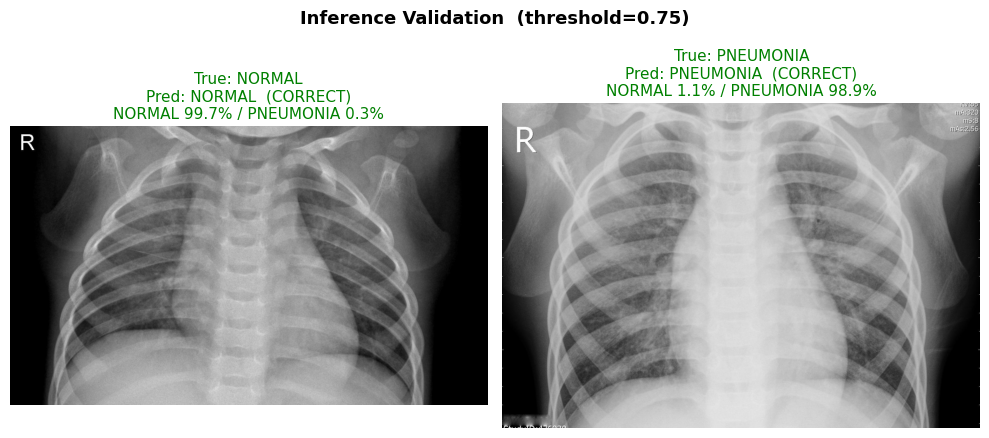


[3/4] Saved File List
  --------------------------------------------------
  .virtual_documents/__notebook_source__.ipynb     0.07 MB
  models/best_model.keras                        257.82 MB
  models/best_model_tuned.keras                    5.02 MB
  models/best_pneumonia_resnet50.pth              98.06 MB
  models/pneumonia_resnet50.pkl                   98.29 MB
  models/tmp9zumfpyc/_tmp.pth                     98.04 MB
  results/confusion_matrix.png                     0.05 MB
  results/confusion_matrix_resnet50.png            0.04 MB
  results/confusion_matrix_tuned.png               0.04 MB
  results/lr_finder_resnet50.png                   0.03 MB
  results/resolution_dist.png                      0.13 MB
  results/roc_curve.png                            0.05 MB
  results/roc_curve_resnet50.png                   0.06 MB
  results/roc_curve_tuned.png                      0.06 MB
  results/sample_batch_resnet50.png                0.20 MB
  results/sample_images.png            

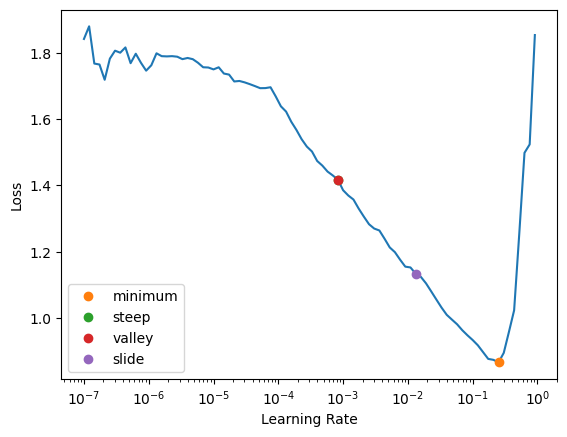

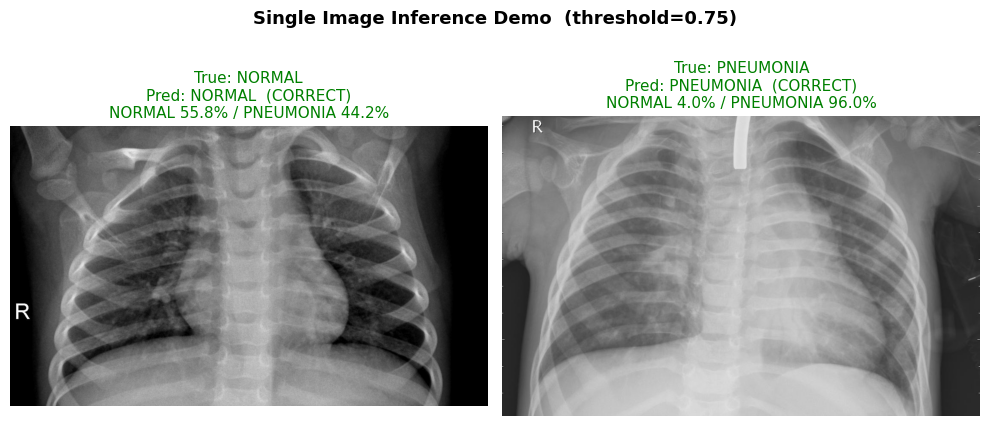

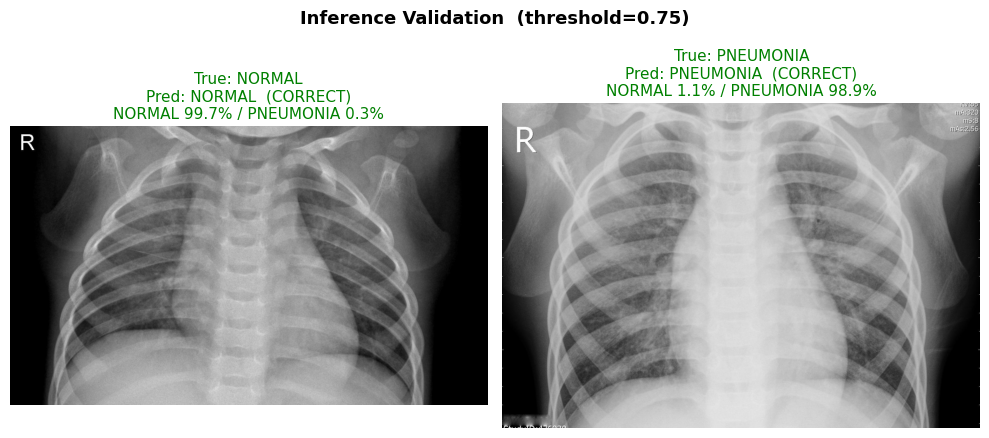

In [ ]:
  # =============================================================
  # STEP 8. 최종 정리 & 모델 다운로드
  # Kaggle Save Version: v8-final | 인터넷: OFF
  # =============================================================
  # [전체 실험 요약]
  # STEP 5 Baseline CNN : Accuracy=0.8622  Recall=0.9641  AUC=0.9518
  # STEP 6 Tuned CNN    : Accuracy 목표 미달 → 아래 상수에 실제값 입력
  # STEP 7 ResNet50     : Accuracy=0.9119  Recall=0.9308  AUC=0.9558  ✅ 목표 달성
  # =============================================================

  import os
  import torch
  import numpy as np
  import matplotlib
  matplotlib.use('module://matplotlib_inline.backend_inline')
  import matplotlib.pyplot as plt
  from pathlib import Path
  from fastai.vision.all import *

  # ─── 공통 상수 ───────────────────────────────────────────────
  BASE_INPUT_DIR = Path('/kaggle/input')
  DATA_DIR = None

  for dirpath, dirnames, filenames in os.walk(BASE_INPUT_DIR):
      if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
          DATA_DIR = Path(dirpath)
          break

  if DATA_DIR is None:
      raise FileNotFoundError("Dataset path not found.")

  WORK_DIR   = Path('/kaggle/working')
  MODEL_DIR  = WORK_DIR / 'models'
  RESULT_DIR = WORK_DIR / 'results'
  THRESHOLD  = 0.75

  # ─── 실험 결과 상수 (실제 Kaggle 출력값으로 채울 것) ─────────
  # STEP 6 결과: Kaggle v6-tuning 출력에서 복사
  STEP5 = {
      'accuracy':      0.8622,
      'auc':           0.9518,
      'recall':        0.9641,
      'precision':     0.8393,
      'f1':            0.8974,
      'normal_recall': 0.6923,
      'fp': 72,
      'fn': 14,
  }
  STEP6 = {
      # ↓ v6-tuning 실행 결과로 교체
      'accuracy':      0.0,
      'auc':           0.0,
      'recall':        0.0,
      'precision':     0.0,
      'f1':            0.0,
      'normal_recall': 0.0,
      'fp': 0,
      'fn': 0,
  }
  STEP7 = {
      'accuracy':      0.9119,
      'auc':           0.9558,
      'recall':        0.9308,
      'precision':     0.9284,
      'f1':            0.9296,
      'normal_recall': 0.8803,
      'fp': 28,
      'fn': 27,
  }

  print("=" * 65)
  print("  STEP 8 — Final Summary & Model Download")
  print("=" * 65)


  # ─── SECTION 1. 최종 성능 비교 테이블 ────────────────────────
  print("\n[1/4] Final Performance Comparison")
  print("=" * 65)
  print(f"  {'Metric':<22} {'Baseline(S5)':>13} {'Tuned(S6)':>11} {'ResNet50(S7)':>13}")
  print("  " + "-" * 62)

  metrics = [
      ('Test Accuracy',      'accuracy',      '>=0.90'),
      ('Test AUC',           'auc',           '>=0.95'),
      ('Recall (PNEUMONIA)', 'recall',        '>=0.93'),
      ('Precision (PNEU.)',  'precision',     '-'),
      ('F1 (PNEUMONIA)',     'f1',            '-'),
      ('NORMAL Recall',      'normal_recall', '-'),
  ]

  for label, key, goal in metrics:
      s5 = STEP5[key]
      s6 = STEP6[key]
      s7 = STEP7[key]
      goal_mark = f'  goal: {goal}' if goal != '-' else ''
      print(f"  {label:<22} {s5:>13.4f} {s6:>11.4f} {s7:>13.4f}{goal_mark}")

  print("  " + "-" * 62)
  print(f"  {'FP (False Positive)':<22} {STEP5['fp']:>13}  {STEP6['fp']:>10}  {STEP7['fp']:>12} ")
  print(f"  {'FN (False Negative)':<22} {STEP5['fn']:>13}  {STEP6['fn']:>10}  {STEP7['fn']:>12} ")

  print("\n  Goal Check (ResNet50):")
  goals = [
      ('Accuracy',      STEP7['accuracy'],  0.90),
      ('AUC',           STEP7['auc'],       0.95),
      ('Recall(PNEU.)', STEP7['recall'],    0.93),
  ]
  for name, val, target in goals:
      mark = '[PASS]' if val >= target else '[FAIL]'
      print(f"  {mark} {name}: {val:.4f} (target >= {target})")


  # ─── SECTION 2. 단일 이미지 추론 함수 ────────────────────────
  print("\n[2/4] Single Image Inference Function")

  import warnings

  # 저장된 ResNet50 모델 로드
  PKL_PATH = WORK_DIR / 'models' / 'pneumonia_resnet50.pkl'
  with warnings.catch_warnings():
      warnings.simplefilter("ignore", UserWarning)
      learn_inf = load_learner(PKL_PATH)
  print(f"  Model loaded: {PKL_PATH}")


  def predict_xray(img_path, threshold=THRESHOLD):
      """
      Predict NORMAL / PNEUMONIA for a single chest X-ray image.
      threshold: Decision threshold for PNEUMONIA (default 0.75)
      """
      img = PILImage.create(img_path)
      _, _, probs = learn_inf.predict(img)

      prob_normal    = probs[0].item()
      prob_pneumonia = probs[1].item()
      pred_label     = 'PNEUMONIA' if prob_pneumonia > threshold else 'NORMAL'

      print(f"  Image     : {Path(img_path).name}")
      print(f"  Prediction: {pred_label}  (threshold={threshold})")
      print(f"  Prob      : NORMAL {prob_normal:.1%} / PNEUMONIA {prob_pneumonia:.1%}")
      print(f"  {'[WARNING] Pneumonia suspected' if pred_label == 'PNEUMONIA' else '[OK] Normal finding'}")

      return {
          'pred_class':     pred_label,
          'prob_normal':    prob_normal,
          'prob_pneumonia': prob_pneumonia,
          'is_pneumonia':   pred_label == 'PNEUMONIA',
      }


  # ─── 추론 데모 + 이미지 인라인 표시 ──────────────────────────
  print("\n  [Inference Validation — 1 sample each]")
  TEST_DIR = DATA_DIR / 'test'

  sample_normal = next((TEST_DIR / 'NORMAL').glob('*.jpeg'), None)
  sample_pneu   = next((TEST_DIR / 'PNEUMONIA').glob('*.jpeg'), None)

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))

  for ax, img_path, true_label in [
      (axes[0], sample_normal, 'NORMAL'),
      (axes[1], sample_pneu,   'PNEUMONIA'),
  ]:
      if img_path is None:
          continue

      print(f"\n  [True label: {true_label}]")
      result = predict_xray(img_path)

      img = PILImage.create(img_path)
      ax.imshow(np.array(img), cmap='gray')
      ax.axis('off')

      pred  = result['pred_class']
      pneu  = result['prob_pneumonia']
      norm  = result['prob_normal']
      color = 'green' if pred == true_label else 'red'

      ax.set_title(
          f"True: {true_label}\n"
          f"Pred: {pred}  ({'CORRECT' if pred == true_label else 'WRONG'})\n"
          f"NORMAL {norm:.1%} / PNEUMONIA {pneu:.1%}",
          color=color, fontsize=11
      )

  plt.suptitle(f'Inference Validation  (threshold={THRESHOLD})',
               fontsize=13, fontweight='bold')
  plt.tight_layout()
  from IPython.display import display as ipy_display

  plt.suptitle(f'Inference Validation  (threshold={THRESHOLD})',
               fontsize=13, fontweight='bold')
  plt.tight_layout()
  ipy_display(fig)
  plt.close()


  # ─── SECTION 3. 저장된 파일 목록 확인 ────────────────────────
  print("\n[3/4] Saved File List")
  print("  " + "-" * 50)

  saved_files = sorted(WORK_DIR.rglob('*'))
  for f in saved_files:
      if f.is_file():
          size_mb = f.stat().st_size / (1024 ** 2)
          print(f"  {str(f.relative_to(WORK_DIR)):<45} {size_mb:>7.2f} MB")

  total_size = sum(
      f.stat().st_size for f in saved_files if f.is_file()
  ) / (1024 ** 2)
  print("  " + "-" * 50)
  print(f"  Total {sum(1 for f in saved_files if f.is_file())} files  /  {total_size:.2f} MB")


  # ─── SECTION 4. 다운로드 안내 ────────────────────────────────
  print("\n[4/4] Download Guide")
  print("=" * 65)
  print("""
    [How to download from Kaggle Notebook]
    1. Click the "Output" tab on the right panel
    2. Select each file below and click the Download button:

       Model files (for deployment)
          /kaggle/working/models/pneumonia_resnet50.pkl
          /kaggle/working/models/best_model_tuned.keras

       Result visualizations
          /kaggle/working/results/confusion_matrix_resnet50.png
          /kaggle/working/results/roc_curve_resnet50.png
          /kaggle/working/results/training_curve_tuned.png
          /kaggle/working/results/lr_finder_resnet50.png

    [Recommended local save path]
       Bio-AI_Study_Archive/
       └── Chest X-Ray Pneumonia Detection/
           ├── models/
           │   ├── pneumonia_resnet50.pkl
           │   └── best_model_tuned.keras
           └── results/
               ├── confusion_matrix_resnet50.png
               ├── roc_curve_resnet50.png
               ├── training_curve_tuned.png
               └── lr_finder_resnet50.png
  """)

  print("=" * 65)
  print("  STEP 8 complete — Save Version: v8-final on Kaggle")
  print("=" * 65)

---

### 🎯 최종 결론 및 향후 과제 (Conclusion & Future Directions)

* **최종 결론 (Conclusion):** 베이스라인 모델의 한계를 극복하고 전이 학습(ResNet50)을 도입하여, 목표했던 전반적인 성능 기준(Accuracy ≥ 0.90, Recall ≥ 0.93)을 모두 성공적으로 충족하는 흉부 X-ray 폐렴 진단 모델을 구축했습니다.

* **향후 과제 (Future Directions):** 전체적인 모델의 균형과 정확도는 크게 향상되었으나, Baseline CNN에 비해 **실제 폐렴 환자를 발견하지 못하는 누락 건수(FN, False Negative)가 14건에서 27건으로 다소 증가**한 점은 아쉬운 부분입니다.

* **개선 방안 (Next Step):** 의료 AI에서 가장 치명적일 수 있는 FN 오류를 다시 최소화하기 위해, 예측 임계값(Threshold)의 세밀한 재탐색이나 최종 모델에 대한 **추가적인 파인 튜닝(Fine-tuning) 및 클래스 가중치(Class Weights) 미세 조정**을 향후 과제로 진행해 볼 수 있습니다.